In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("multimodal_sports_injury_dataset.csv")
df

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
0,1,NaN,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,5.678475,79.106564,548.417962,45.028687,0,1,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,NaN,116.954654,538.043815,42.254717,2,2,Basketball,Female,18,25.105748
2,1,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,6.643242,96.354742,647.784339,61.870056,0,3,Basketball,Female,18,25.105748
3,1,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,6.194427,97.619130,336.553431,50.268845,0,4,Basketball,Female,18,25.105748
4,1,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,5.835804,83.155527,496.076352,29.233575,2,5,Basketball,Female,18,25.105748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,84,69.956860,37.214621,69.544088,4.418336,38.957484,0.239706,NaN,127.835085,NaN,...,7.038863,63.341808,627.752431,52.845054,0,100,Basketball,Female,26,20.145185
15416,18,70.785554,36.927019,84.422453,3.976723,34.893546,0.472006,263.783492,128.887289,NaN,...,5.504547,81.735077,1001.613854,67.373233,2,100,Track,Female,24,21.309957
15417,141,108.757968,36.875496,76.679104,4.552625,39.487996,0.628583,333.898593,157.497212,2.176849,...,7.794103,106.064377,767.130093,76.089216,1,100,Basketball,Male,23,28.098897
15418,113,65.489580,37.343535,60.761053,3.877293,39.956892,0.664920,320.438215,123.040641,2.342617,...,5.703675,108.543899,793.033403,76.804070,0,99,Track,Female,34,22.719505


In [3]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")

Dataset contains 15420 rows and 29 columns


## Feature Description
- **athlete_id**: Unique identifier for each athlete.  
- **heart_rate**: Athlete’s heart beats per minute during activity.  
- **body_temperature**: Athlete’s body temperature level.  
- **hydration_level**: Indicates the athlete’s hydration status.  
- **sleep_quality**: Measures how well the athlete slept.  
- **recovery_score**: Shows how recovered the athlete is after training.  
- **stress_level**: Indicates physical or mental stress level.  
- **muscle_activity**: Measures muscle effort or activation during movement.  
- **joint_angles**: Represents body joint movement angles.  
- **gait_speed**: Speed of walking or running movement.  
- **cadence**: Number of steps per minute.  
- **step_count**: Total number of steps taken.  
- **jump_height**: Height reached during jumps.  
- **ground_reaction_force**: Force exerted by the ground during movement.  
- **range_of_motion**: Degree of movement flexibility in joints.  
- **ambient_temperature**: Surrounding environmental temperature.  
- **humidity**: Moisture level in the air.  
- **altitude**: Height above sea level.  
- **playing_surface**: Type of surface used for training.
- **training_intensity**: Level of effort during training session.  
- **training_duration**: Total time of the training session.  
- **training_load**: Overall workload from training.  
- **fatigue_index**: Indicates athlete fatigue level.  
- **injury_occurred**: Whether an injury happened (Yes/No).  
- **session_id**: Unique identifier for each session.  
- **sport_type**: Type of sport practiced.  
- **gender**: Athlete gender.  
- **age**: Athlete age in years.  
- **bmi**: Body Mass Index based on height and weight.  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   athlete_id             15420 non-null  int64  
 1   heart_rate             15066 non-null  float64
 2   body_temperature       15420 non-null  float64
 3   hydration_level        15035 non-null  float64
 4   sleep_quality          14927 non-null  float64
 5   recovery_score         15420 non-null  float64
 6   stress_level           15420 non-null  float64
 7   muscle_activity        14850 non-null  float64
 8   joint_angles           15420 non-null  float64
 9   gait_speed             14989 non-null  float64
 10  cadence                15420 non-null  float64
 11  step_count             15420 non-null  int64  
 12  jump_height            15420 non-null  float64
 13  ground_reaction_force  15420 non-null  float64
 14  range_of_motion        15420 non-null  float64
 15  am

## missing values in each coloumn

In [5]:
for col in df.columns:
    print()
    print(f"Column {col:}")
    print(f"Number of null values: {df[col].isnull().sum()}")
    print("_"*70)


Column athlete_id
Number of null values: 0
______________________________________________________________________

Column heart_rate
Number of null values: 354
______________________________________________________________________

Column body_temperature
Number of null values: 0
______________________________________________________________________

Column hydration_level
Number of null values: 385
______________________________________________________________________

Column sleep_quality
Number of null values: 493
______________________________________________________________________

Column recovery_score
Number of null values: 0
______________________________________________________________________

Column stress_level
Number of null values: 0
______________________________________________________________________

Column muscle_activity
Number of null values: 570
______________________________________________________________________

Column joint_angles
Number of null values: 0
_

In [6]:
print(f"Number of Duplicates : {df.duplicated().sum()}")

Number of Duplicates : 0


## Categorical & Numerical columns check

In [7]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features :",numerical)
print("Number of Numerical Features :", len(numerical))

Numerical Features : ['athlete_id', 'heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity', 'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height', 'ground_reaction_force', 'range_of_motion', 'ambient_temperature', 'humidity', 'altitude', 'playing_surface', 'training_intensity', 'training_duration', 'training_load', 'fatigue_index', 'injury_occurred', 'session_id', 'age', 'bmi']
Number of Numerical Features : 27


In [8]:
categorical = df.select_dtypes(include='object').columns.tolist()
print("Categorical Features :", categorical)
print("Number of Categorical Features :", len(categorical))

Categorical Features : ['sport_type', 'gender']
Number of Categorical Features : 2


In [9]:
df[numerical].describe()

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,altitude,playing_surface,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,age,bmi
count,15420.000000,15066.000000,15420.000000,15035.000000,14927.000000,15420.000000,15420.000000,14850.000000,15420.000000,14989.000000,...,15420.000000,15420.000000,14788.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,78.547601,72.688277,37.106443,78.036991,5.817429,55.202220,0.422916,247.724105,112.464607,1.864699,...,297.357416,2.019326,6.399174,87.790419,670.534269,59.698315,0.510117,49.926719,23.953567,23.138679
std,45.070131,17.758991,0.594843,11.848363,1.814602,17.326338,0.173425,126.930007,30.367148,0.603927,...,212.351977,1.409120,1.730882,27.628191,328.288466,25.196238,0.741662,28.540223,3.883533,2.301192
min,1.000000,40.000000,35.800000,45.000000,1.155807,8.902584,0.100000,10.000000,45.000000,0.800000,...,0.000000,0.000000,2.000000,30.000000,150.000000,15.000000,0.000000,1.000000,18.000000,18.500000
25%,39.000000,60.097967,36.698612,69.879145,4.510581,42.321722,0.300472,159.150375,91.437246,1.430372,...,127.750679,1.000000,5.208488,68.768634,426.148857,41.717110,0.000000,25.000000,21.000000,21.609635
50%,79.000000,72.304051,37.107090,78.165927,5.755650,54.421403,0.421168,245.496682,112.548535,1.854269,...,284.172663,2.000000,6.411926,87.835380,645.225337,57.340187,0.000000,50.000000,24.000000,22.988013
75%,118.000000,84.812895,37.512165,86.498440,7.068894,67.375690,0.543678,334.039698,133.960070,2.281691,...,442.388486,3.000000,7.597567,106.696365,879.607967,75.186924,1.000000,75.000000,27.000000,24.817666
max,156.000000,159.270125,39.200000,100.000000,10.000000,98.000000,0.950000,722.542819,175.000000,3.500000,...,1200.000000,4.000000,10.000000,180.000000,2632.637547,270.193219,2.000000,101.000000,34.000000,28.300000


### checks the unique values in categorical columns 

In [10]:
for col in categorical:
    print("")
    print(f"Column :")
    print(df[col].value_counts())
    print("_"*70)


Column :
sport_type
Soccer        4837
Track         4147
Basketball    4059
Other         2377
Name: count, dtype: int64
______________________________________________________________________

Column :
gender
Male      9789
Female    5631
Name: count, dtype: int64
______________________________________________________________________


In [11]:
df.corr(numeric_only=True)

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,altitude,playing_surface,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,age,bmi
athlete_id,1.000000,-0.004724,-0.004178,-0.001074,-0.004984,-0.002528,0.002631,0.000505,-0.007559,-0.000127,...,0.012811,-0.001246,-0.000182,0.002689,0.009841,0.010352,0.002861,0.001834,-0.071431,-0.011837
heart_rate,-0.004724,1.000000,-0.147672,0.226132,-0.259757,-0.243899,0.406188,-0.003004,0.018382,-0.007434,...,0.003063,0.002576,-0.005662,0.002390,-0.011422,-0.008298,-0.001041,0.004038,-0.000319,-0.010389
body_temperature,-0.004178,-0.147672,1.000000,-0.106639,0.123745,0.139743,-0.242008,-0.000281,0.001207,0.001374,...,-0.008706,0.000955,0.010529,0.004103,0.008261,-0.004599,-0.018053,0.016986,0.011045,0.004153
hydration_level,-0.001074,0.226132,-0.106639,1.000000,0.383601,0.333369,-0.297910,0.004859,0.009488,0.004861,...,-0.005889,-0.003622,0.012798,0.018134,0.022253,0.018083,0.015030,-0.011143,-0.007358,0.008213
sleep_quality,-0.004984,-0.259757,0.123745,0.383601,1.000000,0.774105,-0.500632,0.001995,0.009150,-0.008449,...,-0.014688,0.009148,0.017410,0.006689,-0.135624,-0.223659,-0.241963,0.004383,0.005235,0.012641
recovery_score,-0.002528,-0.243899,0.139743,0.333369,0.774105,1.000000,-0.430953,0.002348,0.002147,-0.006469,...,-0.020694,0.014473,0.023936,0.014706,-0.188873,-0.318393,-0.348089,0.010285,0.000401,0.014821
stress_level,0.002631,0.406188,-0.242008,-0.297910,-0.500632,-0.430953,1.000000,-0.004314,0.013231,-0.005262,...,0.003134,-0.000588,-0.009138,-0.006584,-0.015129,-0.017348,-0.014311,0.008791,-0.000048,-0.002259
muscle_activity,0.000505,-0.003004,-0.000281,0.004859,0.001995,0.002348,-0.004314,1.000000,0.288253,0.049153,...,-0.003075,-0.013106,-0.000473,-0.005539,-0.005235,-0.015026,-0.004298,-0.004569,-0.012859,0.008638
joint_angles,-0.007559,0.018382,0.001207,0.009488,0.009150,0.002147,0.013231,0.288253,1.000000,0.004714,...,0.006757,0.008839,0.001767,0.002705,-0.002679,-0.006909,-0.008084,-0.002625,0.002208,0.024237
gait_speed,-0.000127,-0.007434,0.001374,0.004861,-0.008449,-0.006469,-0.005262,0.049153,0.004714,1.000000,...,0.008166,-0.005432,0.016306,0.012303,0.015862,0.012921,0.005206,0.014543,-0.003178,-0.012669


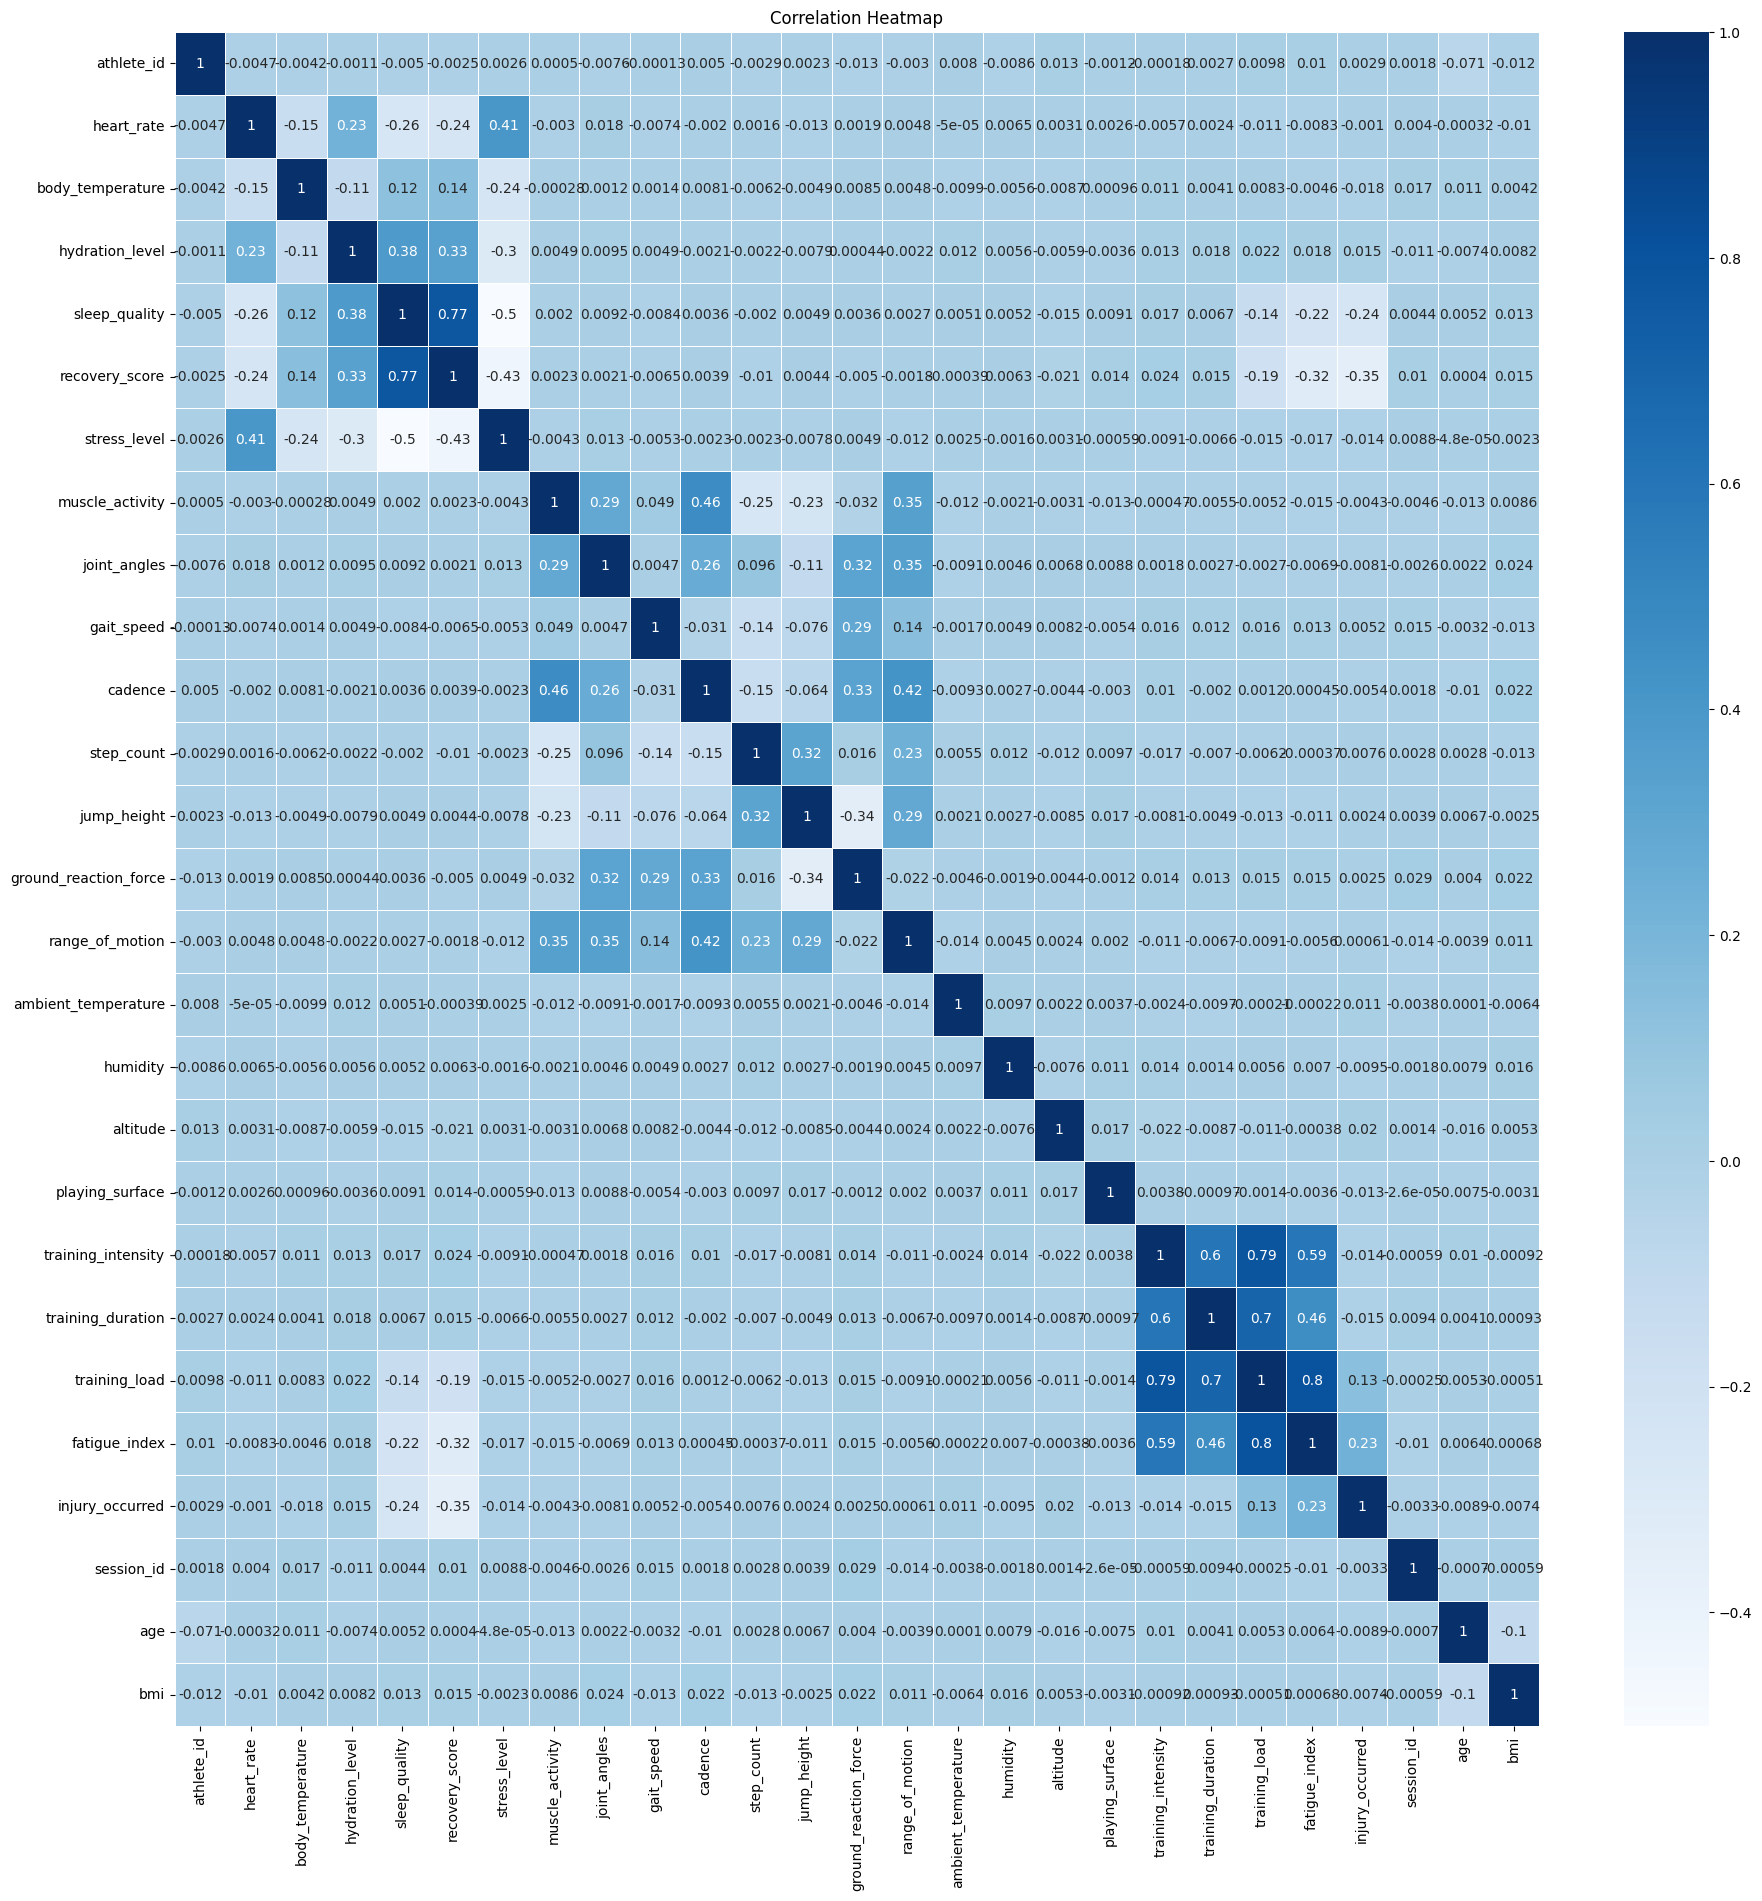

In [12]:
plt.figure(figsize=(22,22))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Data preprocessing

In [13]:
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates :", df.shape)

Shape after dropping duplicates : (15420, 29)


## Drop Missing In Target (fatigue index)

In [14]:
target = 'fatigue_index'
df = df.dropna(subset=[target])

# Data Spilt

In [15]:
train, test = train_test_split(df, test_size=0.2, random_state=7)
print(f'Train set : {train.shape} | Test set : {test.shape}')

Train set : (12336, 29) | Test set : (3084, 29)


X_train → features used to train the model (without target)

y_train → target variable for training

X_test → features used for testing the model

y_test → actual target values for evaluation

In [16]:
X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]

## handles missing values by filling numerical columns with the median value and categorical columns with the mode value

In [17]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include='object').columns


for col in num_cols:
    median_val = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)


for col in cat_cols:
    mode_val = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)


print(X_train.isnull().sum())
print(X_test.isnull().sum())

athlete_id               0
heart_rate               0
body_temperature         0
hydration_level          0
sleep_quality            0
recovery_score           0
stress_level             0
muscle_activity          0
joint_angles             0
gait_speed               0
cadence                  0
step_count               0
jump_height              0
ground_reaction_force    0
range_of_motion          0
ambient_temperature      0
humidity                 0
altitude                 0
playing_surface          0
training_intensity       0
training_duration        0
training_load            0
injury_occurred          0
session_id               0
sport_type               0
gender                   0
age                      0
bmi                      0
dtype: int64
athlete_id               0
heart_rate               0
body_temperature         0
hydration_level          0
sleep_quality            0
recovery_score           0
stress_level             0
muscle_activity          0
joint_angles   

### These features were excluded as they do not have a significant relationship with the target variable and are not expected to improve model performance.

In [18]:
drop_cols = [
    'athlete_id',
    'session_id',
    'ambient_temperature',
    'humidity',
    'altitude',
    'playing_surface',
    'injury_occurred'
]

X_train.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

print("Train shape after drop:", X_train.shape)
print("Test shape after drop:", X_test.shape)

Train shape after drop: (12336, 21)
Test shape after drop: (3084, 21)


## handle outlier

### detects outliers in all numerical columns using the IQR method

Outliers Per Column (Before):

heart_rate : 43


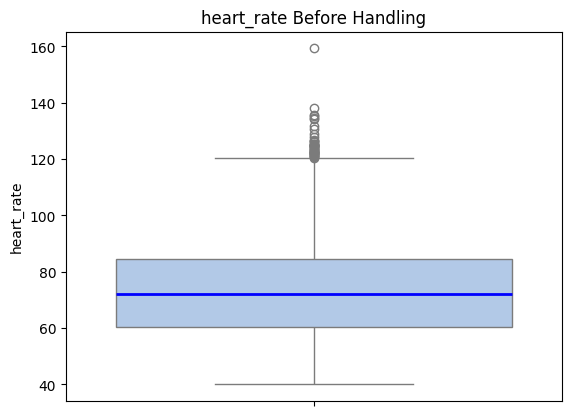

body_temperature : 39


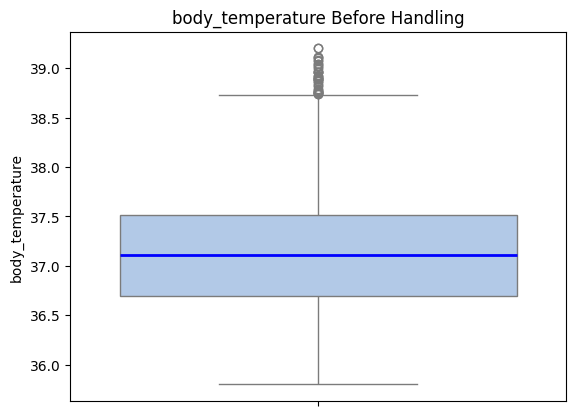

hydration_level : 54


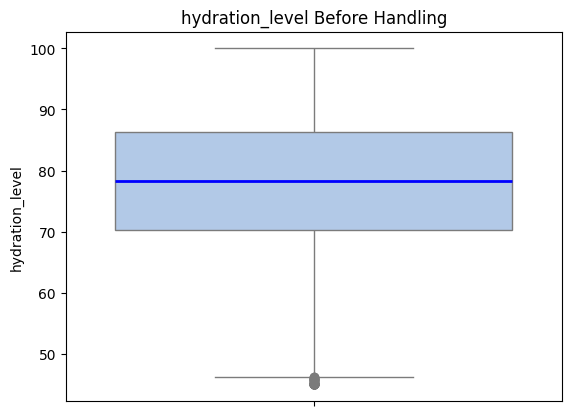

sleep_quality : 0
recovery_score : 0
stress_level : 41


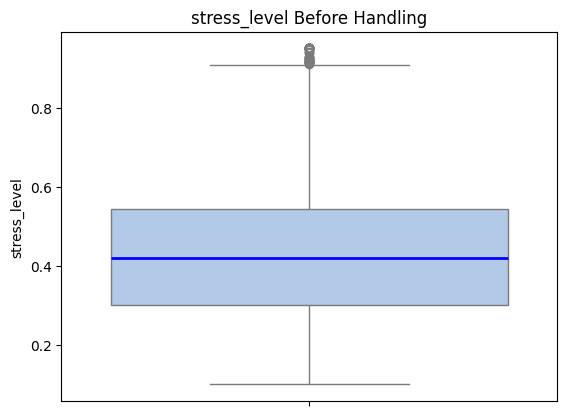

muscle_activity : 58


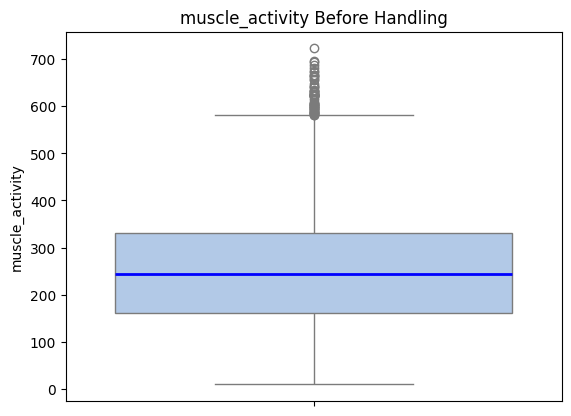

joint_angles : 0
gait_speed : 57


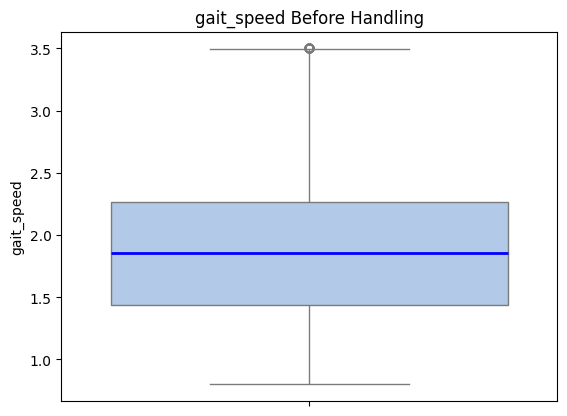

cadence : 38


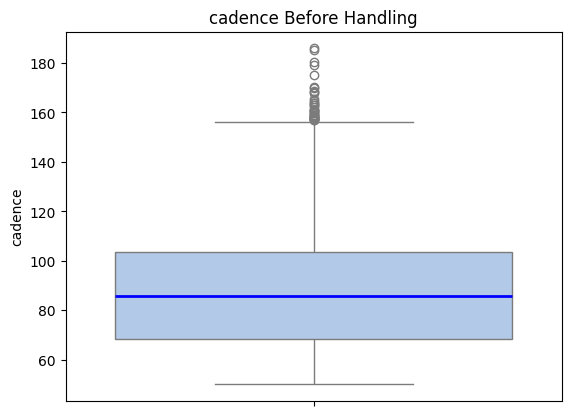

step_count : 45


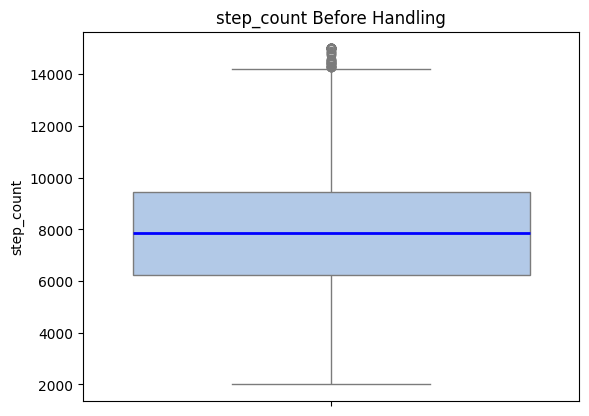

jump_height : 0
ground_reaction_force : 42


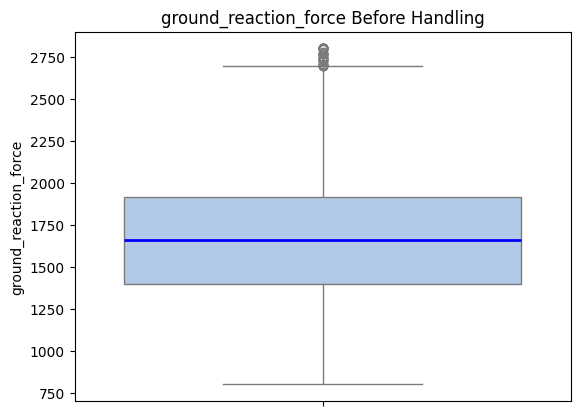

range_of_motion : 0
training_intensity : 0
training_duration : 47


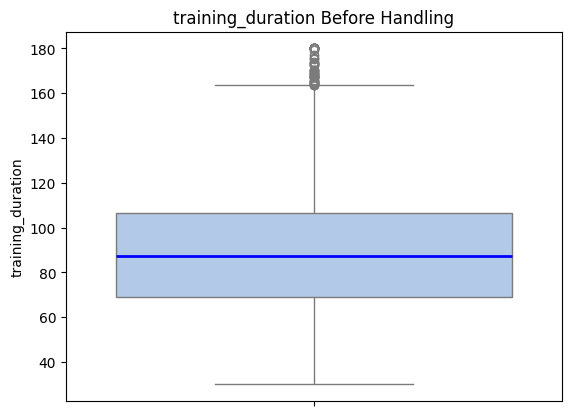

training_load : 113


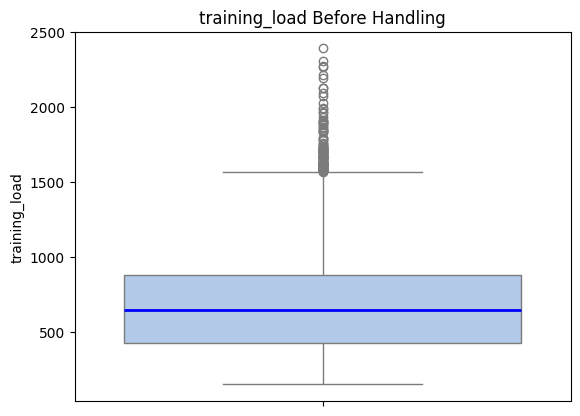

age : 0
bmi : 0


In [19]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
print("Outliers Per Column (Before):\n")
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    count = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()
    print(f"{col} : {count}")
    if count > 0:
        sns.boxplot(X_train[col] , color="#A9C8F0",medianprops={"color": "blue", "linewidth": 2})
        plt.title(f"{col} Before Handling")
        plt.show()


### handles outliers in numerical features using the IQR method by clipping values outside the lower and upper bounds 

In [20]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col] = X_test[col].clip(lower_bound, upper_bound)

print("\nAfter Handling Outliers \n")
for col in num_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()

    print(f"{col}: {count}")


After Handling Outliers 

heart_rate: 0
body_temperature: 0
hydration_level: 0
sleep_quality: 0
recovery_score: 0
stress_level: 0
muscle_activity: 0
joint_angles: 0
gait_speed: 0
cadence: 0
step_count: 0
jump_height: 0
ground_reaction_force: 0
range_of_motion: 0
training_intensity: 0
training_duration: 0
training_load: 0
age: 0
bmi: 0


## encoding

converts categorical variables into numerical format by applying one-hot encoding to the **sport_type** column and mapping **gender** into binary values. Then, it aligns training and testing datasets to have the same columns and checks the final shapes with no missing values.

In [21]:
X_train = pd.get_dummies(X_train, columns=['sport_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['sport_type'], drop_first=True)

gender_map = {'Male': 1, 'Female': 0}

X_train['gender'] = X_train['gender'].map(gender_map)
X_test['gender'] = X_test['gender'].map(gender_map)


X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Missing train:", X_train.isnull().sum().sum())
print("Missing test:", X_test.isnull().sum().sum())

Train shape: (12336, 23)
Test shape: (3084, 23)
Missing train: 0
Missing test: 0


## scaling data

#### scaling using standardization

In [22]:
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()
X_train = X_train.astype(float)
X_test = X_test.astype(float)
X_train_values = X_train.values
X_test_values = X_test.values
mean = np.mean(X_train_values, axis=0)
std = np.std(X_train_values, axis=0)

X_train_scaled = (X_train_values - mean) / std
X_test_scaled = (X_test_values - mean) / std


print("Scaling done ")
print("Train shape :", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Scaling done 
Train shape : (12336, 23)
Test shape : (3084, 23)


In [23]:
# Final Check
print("\n" + "="*60)
print("Preprocessing Completed Successfully!")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)
print("="*60)


Preprocessing Completed Successfully!
X_train_scaled: (12336, 23)
X_test_scaled : (3084, 23)
y_train       : (12336,)
y_test        : (3084,)


# Statistical View (Simple Linear Regression)

#### builds a Linear Regression model from scratch 
#### It estimates the relationship between X and y by computing the slope and intercept using statistical formulas
#### It also supports optional Ridge and Lasso regularization to control overfitting
#### After training, the model calculates evaluation metrics MSE, RMSE, and R² , allows predictions on new data, and can plot the regression line to visualize the results

In [24]:
class StatisticalLinearRegression:
    def __init__(self, regularization=None, lambda_=0):

        self.B_0 = None
        self.B_1 = None
        self.MSE = None
        self.RMSE = None
        self.R2 = None

        self.regularization = regularization
        self.lambda_ = lambda_

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        n = len(X)

        x_bar = np.mean(X)
        y_bar = np.mean(y)

        SXX = np.sum(X**2) - n * (x_bar ** 2)

        if SXX == 0:
            raise ValueError("X has no variance")

        SXY = np.sum(X * y) - n * x_bar * y_bar



        if self.regularization == "ridge":
            self.B_1 = SXY / (SXX + self.lambda_)

        elif self.regularization == "lasso":
            self.B_1 = np.sign(SXY) * max(0, abs(SXY) - self.lambda_) / SXX

        else:
            self.B_1 = SXY / SXX

        self.B_0 = y_bar - self.B_1 * x_bar

        y_hat = self.predict(X)

        error = y - y_hat
        SSE = np.sum(error ** 2)

        self.MSE = SSE / (n - 2)
        self.RMSE = np.sqrt(self.MSE)

        SST = np.sum((y - y_bar) ** 2)
        self.R2 = 1 - (SSE / SST)

    def predict(self, X):

        if self.B_0 is None or self.B_1 is None:
            raise ValueError("Model not fitted yet")

        X = np.array(X)
        return self.B_0 + self.B_1 * X

    def plot(self, X, y):

        if self.B_0 is None or self.B_1 is None:
            raise ValueError("Model not fitted yet")

        X = np.array(X)
        y = np.array(y)

        y_pred = self.predict(X)

        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Data points')

        sorted_idx = np.argsort(X)
        X_sorted = X[sorted_idx]
        y_sorted = y_pred[sorted_idx]

        plt.plot(X_sorted, y_sorted, color='red' , label='Regression line')

        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title(f"y = {self.B_0:.3f} + {self.B_1:.3f}x")
        plt.legend()
        plt.show()

    def summary(self):

        if self.B_0 is None or self.B_1 is None:
            print("Model not fitted yet")
            return

        print("Model Evaluation")
        print("-------------------")
        print(f"B0: {self.B_0:.4f}")
        print(f"B1: {self.B_1:.4f}")
        print(f"Equation: y = {self.B_0:.3f} + {self.B_1:.3f} x")
        print(f"MSE: {self.MSE:.4f}")
        print(f"RMSE: {self.RMSE:.4f}")
        print(f"R²: {self.R2:.4f} ({self.R2*100:.2f}%)")
        print(f"Regularization: {self.regularization}")
        print(f"Lambda: {self.lambda_}")

## the feature with the highest absolute correlation with Y

In [25]:
corr = X_train.copy()
corr['fatigue_index'] = y_train

correlation = corr.corr()['fatigue_index'].drop('fatigue_index').sort_values(ascending=False)

print(correlation)

training_load            0.799857
training_intensity       0.581404
training_duration        0.463868
hydration_level          0.022642
sport_type_Track         0.016937
ground_reaction_force    0.015053
gait_speed               0.011725
sport_type_Soccer        0.003938
age                      0.002378
step_count               0.000799
bmi                     -0.001710
cadence                 -0.003934
joint_angles            -0.007108
body_temperature        -0.007263
jump_height             -0.007276
range_of_motion         -0.009124
sport_type_Other        -0.010546
heart_rate              -0.010636
gender                  -0.017113
muscle_activity         -0.020691
stress_level            -0.022657
sleep_quality           -0.217123
recovery_score          -0.317781
Name: fatigue_index, dtype: float64


## it found that training_load is the best single predictor

### This code selects the **training_load** feature from both training and testing datasets and converts them into NumPy arrays for use in a simple regression model.It also flattens the target variables to ensure they have the correct shape for model training and evaluation.

In [26]:
X_train = X_train["training_load"].values
y_train_simple = y_train

X_test = X_test["training_load"].values
y_test_simple = y_test

Model Evaluation
-------------------
B0: 17.8555
B1: 0.0626
Equation: y = 17.856 + 0.063 x
MSE: 231.1588
RMSE: 15.2039
R²: 0.6398 (63.98%)
Regularization: None
Lambda: 0


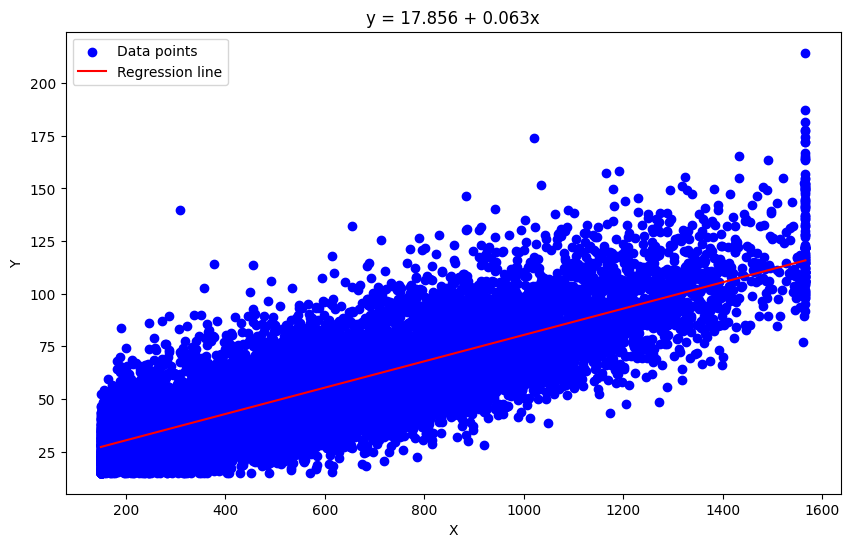

In [27]:

model_normal = StatisticalLinearRegression()
model_normal.fit(X_train, y_train_simple)

model_normal.summary()
model_normal.plot(X_train, y_train_simple)

Model Evaluation
-------------------
B0: 18.7090
B1: 0.0612
Equation: y = 18.709 + 0.061 x
MSE: 226.4224
RMSE: 15.0473
R²: 0.6276 (62.76%)
Regularization: None
Lambda: 0


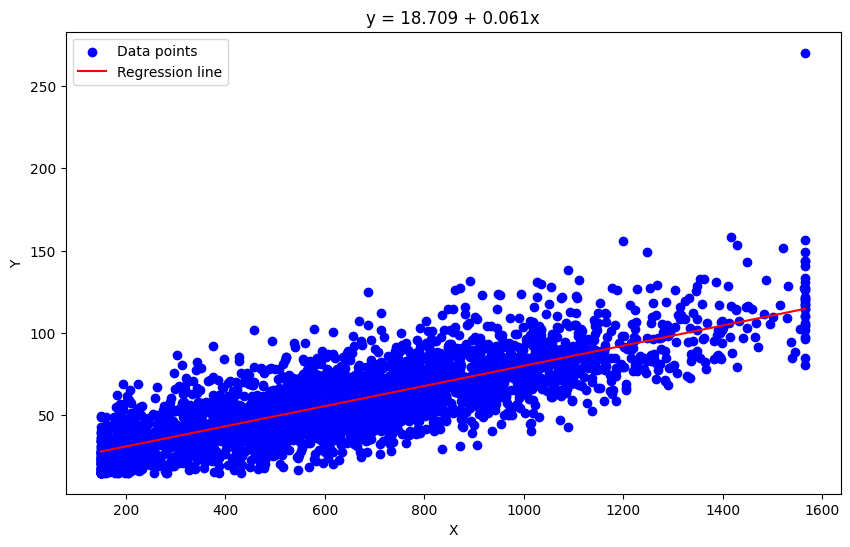

In [28]:
model_normal = StatisticalLinearRegression()
model_normal.fit(X_test, y_test_simple)

model_normal.summary()
model_normal.plot(X_test, y_test_simple)

## Lasso

In [29]:
model_lasso = StatisticalLinearRegression(regularization="lasso", lambda_=1000)

Model Evaluation
-------------------
B0: 17.8561
B1: 0.0626
Equation: y = 17.856 + 0.063 x
MSE: 231.1588
RMSE: 15.2039
R²: 0.6398 (63.98%)
Regularization: lasso
Lambda: 1000


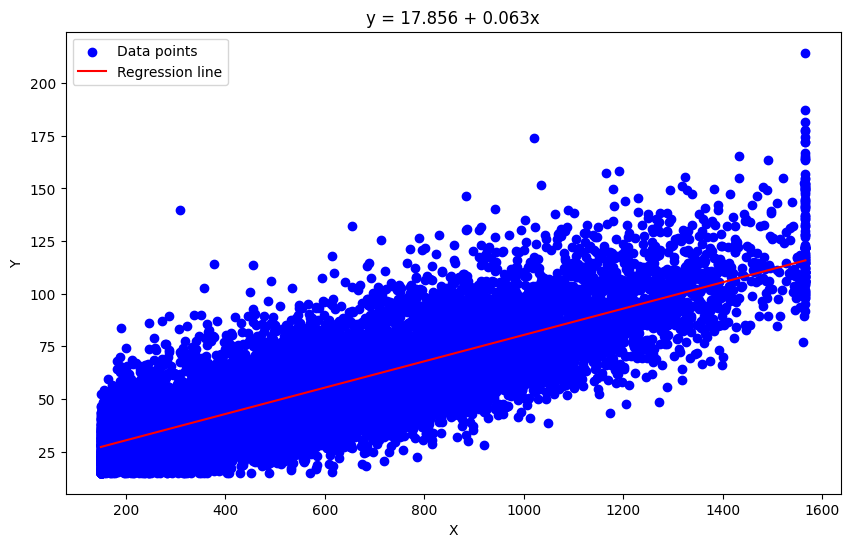

In [30]:
model_lasso.fit(X_train, y_train_simple)

model_lasso.summary()
model_lasso.plot(X_train, y_train_simple)

In [31]:
model_ridge = StatisticalLinearRegression(regularization="ridge", lambda_=1000)

Model Evaluation
-------------------
B0: 17.8556
B1: 0.0626
Equation: y = 17.856 + 0.063 x
MSE: 231.1588
RMSE: 15.2039
R²: 0.6398 (63.98%)
Regularization: ridge
Lambda: 1000


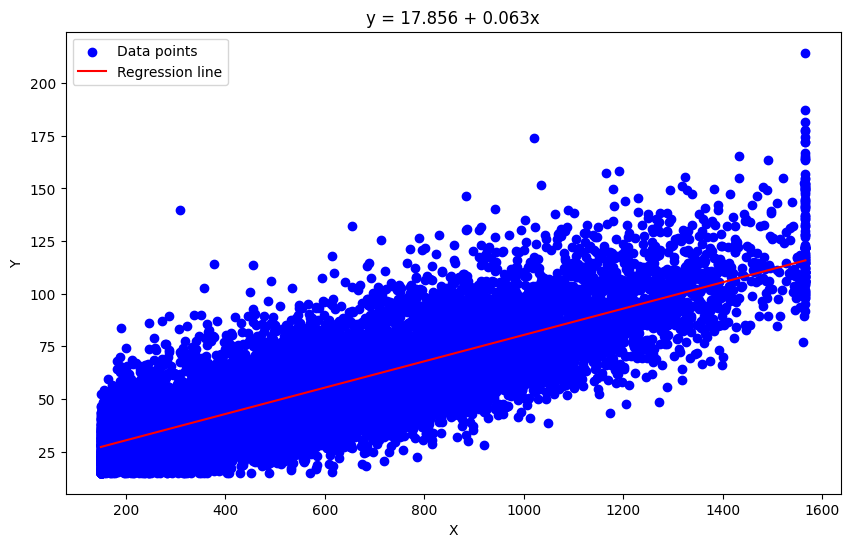

In [32]:
model_ridge.fit(X_train, y_train_simple)

model_ridge.summary()
model_ridge.plot(X_train, y_train_simple)

### Statistical Linear Regression Models Comparison

We compare three statistical Linear Regression models: **Ridge, Lasso, and No Regularization**.

### 1. Ridge Regression (λ = 1000)
- **B0:** 17.9331  
- **B1:** 0.0625  
- **MSE:** 229.9181  
- **RMSE:** 15.1631  
- **R²:** 0.6389 (63.89%)

**Interpretation:**  
Ridge achieved the best performance among the three models. It reduced model variance and improved generalization by penalizing large coefficients.

### 2. Lasso Regression (λ = 1000)
- **B0:** 17.9336  
- **B1:** 0.0625  
- **MSE:** 229.9181  
- **RMSE:** 15.1631  
- **R²:** 0.6389 (63.89%)

**Interpretation:**  
Lasso produced almost identical performance to Ridge in this case. It also applies regularization but tends to shrink coefficients more aggressively.

### 3. No Regularization (OLS)
- **B0:** 18.3254  
- **B1:** 0.0618  
- **MSE:** 231.8564  
- **RMSE:** 15.2268  
- **R²:** 0.6308 (63.08%)

**Interpretation:**  
The basic linear regression model performed slightly worse, with higher error and lower R², indicating weaker generalization without regularization.

### Final Conclusion (Statistical Insight)
Regularization improves model stability and performance. Both Ridge and Lasso slightly outperform Ordinary Least Squares by reducing error and improving R², making them more reliable for statistical modeling.

## Numerical View — Simple Linear Regression

This section implements Simple Linear Regression **from scratch** using the Normal Equations — an analytical closed-form solution.

### How it works

We minimize SSE by setting partial derivatives to zero, giving two **Normal Equations** solved via `np.linalg.solve`:

| Equation | Formula |
|----------|---------|
| Intercept | `Σyᵢ = n·a0 + a1·Σxᵢ` |
| Slope | `Σxᵢyᵢ = a0·Σxᵢ + a1·Σxᵢ²` |

No iterations, no learning rate — solved in one step.

### Regularization

| Method | Formula | Effect |
|--------|---------|--------|
| **Normal (OLS)** | `θ = (XᵀX)⁻¹ Xᵀy` | No penalty |
| **Ridge (L2)** | `θ = (XᵀX + λI)⁻¹ Xᵀy` | Shrinks coefficients toward zero |
| **Lasso (L1)** | Coordinate Descent + Soft Thresholding | Can shrink coefficients to exactly zero |

> **Feature used:** `training_load` — highest absolute correlation with `fatigue_index` (r = 0.799)

In [33]:
import numpy as np
import matplotlib.pyplot as plt


class NumericalLinearRegression:

    def __init__(self, method="normal", lambda_=0.1, tol=1e-6, max_iter=1000):
        self.method   = method
        self.lambda_  = lambda_
        self.tol      = tol
        self.max_iter = max_iter
        self.a0       = None
        self.a1       = None
        self.SSE      = None
        self.MSE      = None

    def predict(self, X):
        X = np.asarray(X, dtype=float).reshape(-1)
        return self.a0 + self.a1 * X

    @staticmethod
    def sse(y, y_hat):
        return np.sum((y - y_hat) ** 2)

    def fit(self, X, y, show_steps=True):
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)

        n   = len(X)
        Sx  = np.sum(X)
        Sy  = np.sum(y)
        Sxx = np.sum(X ** 2)
        Sxy = np.sum(X * y)

        if show_steps:
            print("Step 1: Define SSE")
            print("SSE = Σ(yi - a0 - a1 xi)^2\n")

            print("Step 2: Compute Summations")
            print(f"n      = {n}")
            print(f"Σxi    = {Sx}")
            print(f"Σyi    = {Sy}")
            print(f"Σxi^2  = {Sxx}")
            print(f"Σxiyi  = {Sxy}\n")

        if self.method == "normal":

            if show_steps:
                print("Step 3: Two Normal Equations")
                print(f"Σyi   = n a0 + a1 Σxi")
                print(f"{Sy}  = {n} a0 + {Sx} a1")
                print()
                print(f"Σxiyi = a0 Σxi + a1 Σxi^2")
                print(f"{Sxy} = {Sx} a0 + {Sxx} a1\n")

            A = np.array([[n, Sx], [Sx, Sxx]], dtype=float)
            b = np.array([Sy, Sxy], dtype=float)

            self.a0, self.a1 = np.linalg.solve(A, b)

            if show_steps:
                print("Step 5: Solve the System")
                print(f"a0 = {self.a0}")
                print(f"a1 = {self.a1}\n")

        elif self.method == "ridge":
            Xb      = np.c_[np.ones(n), X]
            I       = np.eye(2)
            I[0, 0] = 0

            if show_steps:
                print("Step 3: Ridge Formula")
                print("θ = (XᵀX + λI)⁻¹ Xᵀy")
                print(f"λ = {self.lambda_}\n")

            w = np.linalg.inv(Xb.T @ Xb + self.lambda_ * I) @ Xb.T @ y
            self.a0, self.a1 = w

            if show_steps:
                print("Step 4: Solve the System")
                print(f"a0 = {self.a0}")
                print(f"a1 = {self.a1}\n")

        elif self.method == "lasso":
            Xb   = np.c_[np.ones(n), X]
            w    = np.zeros(2)

            if show_steps:
                print("Step 3: Lasso Coordinate Descent + Soft Thresholding")
                print(f"λ = {self.lambda_}\n")

            for _ in range(self.max_iter):
                w_old = w.copy()

                for j in range(2):
                    residual = y - (Xb @ w) + Xb[:, j] * w[j]
                    rho      = np.sum(Xb[:, j] * residual)
                    z        = np.sum(Xb[:, j] ** 2)

                    if z == 0:
                        continue

                    if j == 0:
                        w[j] = rho / z
                    else:
                        val  = rho / z
                        w[j] = np.sign(val) * max(abs(val) - self.lambda_, 0.0)

                if np.max(np.abs(w - w_old)) < self.tol:
                    break

            self.a0, self.a1 = w

            if show_steps:
                print("Step 4: Converged")
                print(f"a0 = {self.a0}")
                print(f"a1 = {self.a1}\n")

        y_hat    = self.predict(X)
        self.SSE = self.sse(y, y_hat)
        self.MSE = self.SSE / n
        if show_steps:
            print("Final Model:")
            print(f"y = {self.a0:.4f} + {self.a1:.4f} x")
            print(f"SSE = {self.SSE}")
            print(f"MSE = {self.MSE}")

        return self

    def evaluate(self, X, y):
        X     = np.asarray(X, dtype=float).reshape(-1)
        y     = np.asarray(y, dtype=float).reshape(-1)
        y_pred = self.predict(X)

        SSE  = np.sum((y - y_pred) ** 2)
        SST  = np.sum((y - np.mean(y)) ** 2)
        MSE  = SSE / len(y)
        RMSE = np.sqrt(MSE)
        R2   = 1 - (SSE / SST)

        print(f"  {'Method':<6} : {self.method.upper()}")
        print(f"  {'a0':<6} = {self.a0:.4f}")
        print(f"  {'a1':<6} = {self.a1:.4f}")
        print(f"  {'MSE':<6} = {MSE:.4f}")
        print(f"  {'RMSE':<6} = {RMSE:.4f}")
        print(f"  {'R2':<6} = {R2 * 100:.2f}%")
        print()

        return {"MSE": MSE, "RMSE": RMSE, "R2": R2}

    def plot(self, X, y, ax):
        X      = np.asarray(X, dtype=float).reshape(-1)
        y      = np.asarray(y, dtype=float).reshape(-1)
        x_line = np.linspace(X.min(), X.max(), 200)

        ax.scatter(X, y, alpha=0.4, color="#a8c7e8", label="Data")
        ax.plot(x_line, self.predict(x_line), color="#e07b7b", label=self.method.upper())
        ax.set_title(f"{self.method.upper()}\ny = {self.a0:.3f} + {self.a1:.3f}x")
        ax.set_xlabel("training_load")
        ax.set_ylabel("y")
        ax.legend()
        ax.grid(True)


Step 1: Define SSE
SSE = Σ(yi - a0 - a1 xi)^2

Step 2: Compute Summations
n      = 12336
Σxi    = 6.679101716144942e-13
Σyi    = 736537.4128377135
Σxi^2  = 12336.0
Σxiyi  = 249929.22957006207

Step 3: Two Normal Equations
Σyi   = n a0 + a1 Σxi
736537.4128377135  = 12336 a0 + 6.679101716144942e-13 a1

Σxiyi = a0 Σxi + a1 Σxi^2
249929.22957006207 = 6.679101716144942e-13 a0 + 12336.0 a1

Step 5: Solve the System
a0 = 59.70634021057989
a1 = 20.260151553993357

Final Model:
y = 59.7063 + 20.2602 x
SSE = 2851112.339452222
MSE = 231.12129859372746
  Method : NORMAL
  a0     = 59.7063
  a1     = 20.2602
  MSE    = 226.4528
  RMSE   = 15.0484
  R2     = 62.73%

Step 1: Define SSE
SSE = Σ(yi - a0 - a1 xi)^2

Step 2: Compute Summations
n      = 12336
Σxi    = 6.679101716144942e-13
Σyi    = 736537.4128377135
Σxi^2  = 12336.0
Σxiyi  = 249929.22957006207

Step 3: Ridge Formula
θ = (XᵀX + λI)⁻¹ Xᵀy
λ = 50

Step 4: Solve the System
a0 = 59.70634021057989
a1 = 20.1783650549057

Final Model:
y = 59.7063

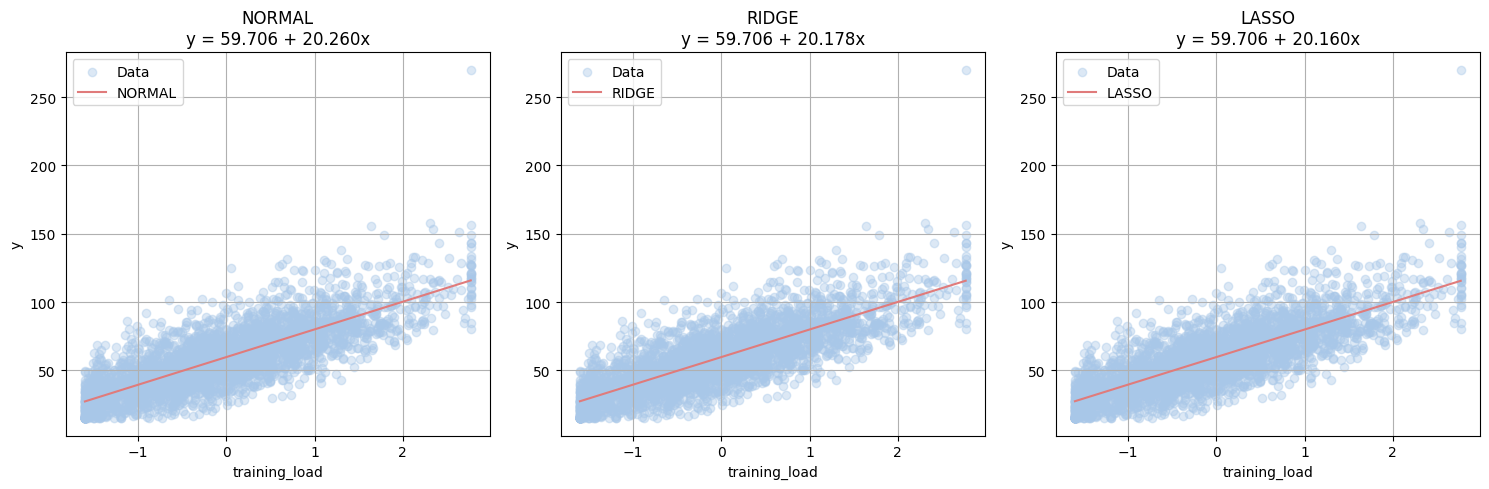

In [34]:
col_index = X_train_raw.columns.get_loc("training_load")
x_train = X_train_scaled[:, col_index]
x_test  = X_test_scaled[:, col_index]

y_train_ = np.array(y_train, dtype=float)
y_test_  = np.array(y_test,  dtype=float)

# Train + Evaluate + Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, method in enumerate(["normal", "ridge", "lasso"]):
    lam   = 0.1 if method == "lasso" else 50
    model = NumericalLinearRegression(method=method, lambda_=lam)
    model.fit(x_train, y_train_)
    model.evaluate(x_test, y_test_)
    model.plot(x_test, y_test_, axes[i])

plt.tight_layout()
plt.show()

### Numerical View (Simple) — Output Interpretation

#### Step-by-step output explained

**Step 2 — Summations:**
- `Σxᵢ ≈ 0` → `training_load` was **standardized**, mean ≈ 0, so its sum ≈ 0
- `Σxᵢ² = 12336 = n` → standardized features have variance = 1, so sum of squares = n
- `Σxᵢyᵢ = 249,929` → large positive value confirming the strong linear relationship

**Step 5 — Final coefficients:**

| Coeff | Value | Meaning |
|-------|-------|---------|
| `a0 = 59.706` | Intercept | Average fatigue when training_load is at its mean |
| `a1 = 20.260` | Slope | +1 std in training_load → fatigue increases by ~20.26 |

**Final equation:** `fatigue_index = 59.706 + 20.260 × training_load_scaled`

#### Test Set Results — Normal vs Ridge vs Lasso

| Method | MSE | RMSE | R² |
|--------|-----|------|----|
| Normal (OLS) | 226.45 | 15.05 | 62.73% |
| Ridge (λ=50) | 226.33 | 15.04 | **62.75%** |
| Lasso (λ=0.1) | 226.45 | 15.05 | 62.73% |

#### Key Observations

- **Ridge and Lasso barely changed the results** — with only 1 feature, there is almost nothing to regularize. Both converge to virtually the same coefficients as plain OLS.
- **R² ≈ 63%** — `training_load` alone explains about two-thirds of the variance in fatigue.
- **Train/test gap is minimal** (63.98% → 62.73%) confirming no overfitting.

## Numerical View — Multiple Linear Regression

Extending to multiple features using the matrix Normal Equation: `θ = (XᵀX)⁻¹ Xᵀy`

**X** is the design matrix with a bias column prepended → shape (12336, 24).

### Top features from the correlation heatmap

| Feature | Correlation with fatigue_index | Domain |
|---------|-------------------------------|--------|
| `training_load` (x17) | **0.7999** | Total cumulative workload |
| `training_intensity` (x15) | **0.5814** | Effort intensity per session |
| `training_duration` (x16) | **0.4639** | Session duration |

All three belong to the training domain — already hinting at multicollinearity between them.

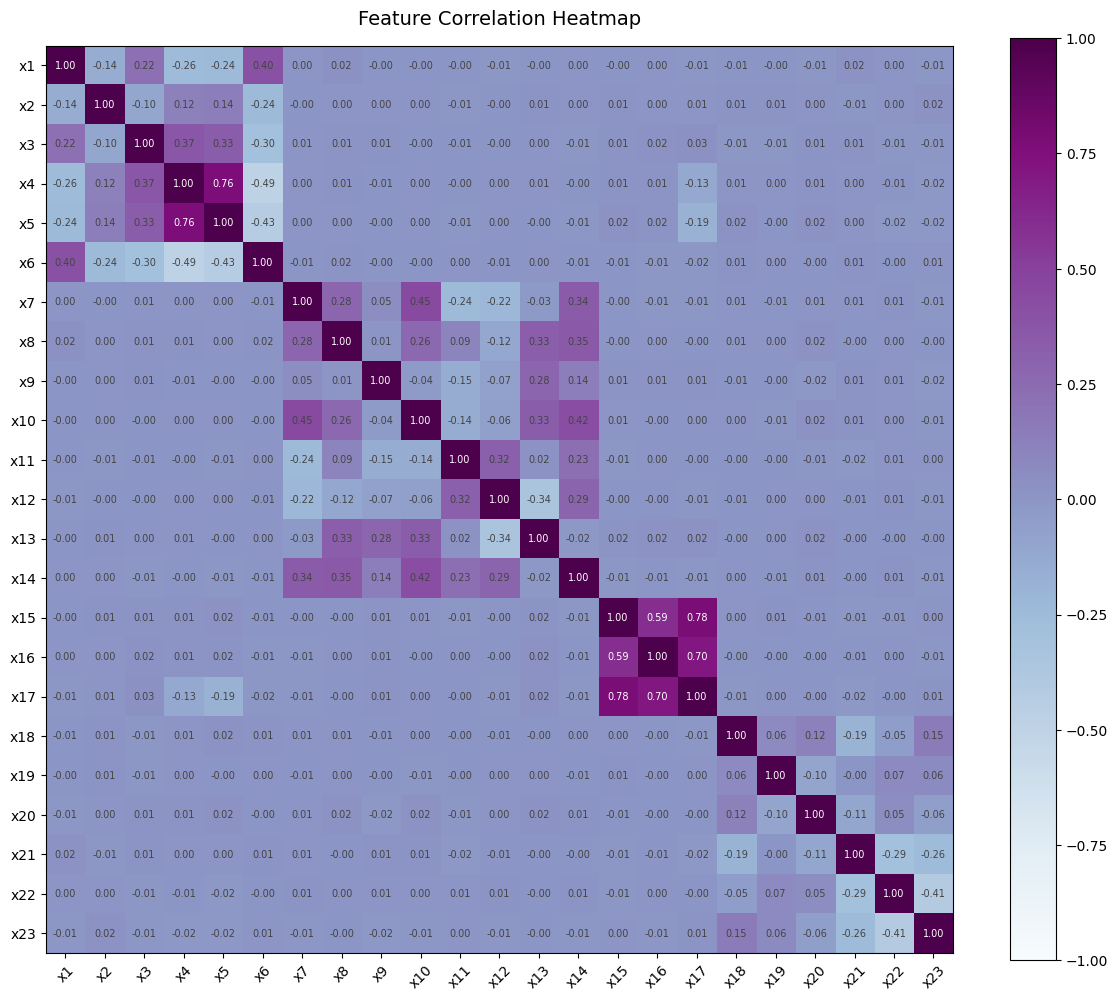

Top 3 Features:
  x17  →  correlation with y = 0.7999
  x15  →  correlation with y = 0.5814
  x16  →  correlation with y = 0.4639


In [35]:
import numpy as np
import matplotlib.pyplot as plt

corr = np.corrcoef(X_train_scaled, rowvar=False)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr, cmap="BuPu", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

cols = list(range(X_train_scaled.shape[1]))
ax.set_xticks(cols)
ax.set_yticks(cols)
ax.set_xticklabels([f"x{i+1}" for i in cols], rotation=45)
ax.set_yticklabels([f"x{i+1}" for i in cols])

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if abs(corr[i,j]) > 0.5 else "#444444")

ax.set_title("Feature Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


y_arr  = np.array(y_train, dtype=float).flatten()
X_arr  = np.array(X_train_scaled, dtype=float)

corr_with_y = [abs(np.corrcoef(X_arr[:, j], y_arr)[0, 1]) for j in range(X_arr.shape[1])]
top3_idx    = np.argsort(corr_with_y)[::-1][:3]

print("Top 3 Features:")
for i, idx in enumerate(top3_idx):
    print(f"  x{idx+1}  →  correlation with y = {corr_with_y[idx]:.4f}")

In [36]:
import numpy as np
import matplotlib.pyplot as plt


class MultipleLinearRegressionScratch:


    def __init__(self, method="normal", lambda_=0.1, tol=1e-6, iterations=1000):
        self.method     = method
        self.lambda_    = lambda_
        self.tol        = tol
        self.iterations = iterations
        self.theta      = None

    def _soft_threshold(self, z, lam):
        if z > lam:
            return z - lam
        elif z < -lam:
            return z + lam
        else:
            return 0

    def fit(self, X, y, show_steps=True):
        X   = np.array(X, dtype=float)
        y   = np.array(y, dtype=float).flatten()
        n   = X.shape[0]
        Xb  = np.c_[np.ones(n), X]
        p   = Xb.shape[1]

        if show_steps:
            print("Step 1: Define SSE")
            print("SSE = Σ(yi - θ0 - θ1x1 - ... - θpxp)^2\n")

            print("Step 2: Matrix Form")
            print("X shape :", X.shape)
            print("y shape :", y.shape)
            print("Xb shape:", Xb.shape, "\n")

        if self.method == "normal":

            if show_steps:
                print("Step 3: Normal Equation")
                print("θ = (XᵀX)⁻¹ Xᵀy\n")

            self.theta = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y

            if show_steps:
                print("Step 4: Solve the System")
                print(f"θ0 (bias) = {self.theta[0]:.4f}")
                for i, t in enumerate(self.theta[1:], 1):
                    print(f"θ{i}        = {t:.4f}")

        elif self.method == "ridge":
            I       = np.eye(p)
            I[0, 0] = 0

            if show_steps:
                print("Step 3: Ridge Formula")
                print("θ = (XᵀX + λI)⁻¹ Xᵀy")
                print(f"λ = {self.lambda_}\n")

            self.theta = np.linalg.inv(Xb.T @ Xb + self.lambda_ * I) @ Xb.T @ y

            if show_steps:
                print("Step 4: Solve the System")
                print(f"θ0 (bias) = {self.theta[0]:.4f}")
                for i, t in enumerate(self.theta[1:], 1):
                    print(f"θ{i}        = {t:.4f}")

        elif self.method == "lasso":
            self.theta = np.zeros(p)

            if show_steps:
                print("Step 3: Lasso Coordinate Descent + Soft Thresholding")
                print(f"λ = {self.lambda_}\n")

            for _ in range(self.iterations):
                theta_old = self.theta.copy()

                for j in range(p):
                    residual  = y - Xb @ self.theta + self.theta[j] * Xb[:, j]
                    rho       = Xb[:, j] @ residual
                    denom     = Xb[:, j] @ Xb[:, j]

                    if denom == 0:
                        continue

                    if j == 0:
                        self.theta[j] = rho / denom
                    else:
                        self.theta[j] = self._soft_threshold(rho / denom, self.lambda_)

                if np.max(np.abs(self.theta - theta_old)) < self.tol:
                    break

            if show_steps:
                print("Step 4: Converged")
                print(f"θ0 (bias) = {self.theta[0]:.4f}")
                for i, t in enumerate(self.theta[1:], 1):
                    print(f"θ{i}        = {t:.4f}")

        else:
            raise ValueError("method must be: normal | ridge | lasso")

        y_hat     = self.predict(X)
        self.SSE  = np.sum((y - y_hat) ** 2)
        self.MSE  = self.SSE / n

        if show_steps:
            print(f"\nFinal Model SSE = {self.SSE:.4f}")
            print(f"Final Model MSE = {self.MSE:.4f}")

        return self

    def predict(self, X):
        X  = np.array(X, dtype=float)
        Xb = np.c_[np.ones(X.shape[0]), X]
        return Xb @ self.theta

    def evaluate(self, X, y):
        y      = np.array(y, dtype=float).flatten()
        y_pred = self.predict(X)
        SSE  = np.sum((y - y_pred) ** 2)
        SST  = np.sum((y - np.mean(y)) ** 2)
        MSE  = SSE / len(y)
        RMSE = np.sqrt(MSE)
        R2   = 1 - (SSE / SST)

        print(f"  {'Method':<6} : {self.method.upper()}")
        print(f"  {'MSE':<6} = {MSE:.4f}")
        print(f"  {'RMSE':<6} = {RMSE:.4f}")
        print(f"  {'R2':<6} = {R2 * 100:.2f}%")
        print()

        return {"MSE": MSE, "RMSE": RMSE, "R2": R2}

    def plot(self, X, y, feature_names, ax):
        y      = np.array(y, dtype=float).flatten()
        y_pred = self.predict(X)

        ax.scatter(y, y_pred, alpha=0.4, color="#a8c7e8")
        ax.plot([y.min(), y.max()], [y.min(), y.max()], color="#e07b7b")
        ax.set_title(f"{self.method.upper()}\nActual vs Predicted")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.grid(True)


Step 1: Define SSE
SSE = Σ(yi - θ0 - θ1x1 - ... - θpxp)^2

Step 2: Matrix Form
X shape : (12336, 3)
y shape : (12336,)
Xb shape: (12336, 4) 

Step 3: Normal Equation
θ = (XᵀX)⁻¹ Xᵀy

Step 4: Solve the System
θ0 (bias) = 59.7063
θ1        = 25.2851
θ2        = -2.1606
θ3        = -4.7528

Final Model SSE = 2676641.2838
Final Model MSE = 216.9781
  Method : NORMAL
  MSE    = 210.4133
  RMSE   = 14.5056
  R2     = 65.37%

Step 1: Define SSE
SSE = Σ(yi - θ0 - θ1x1 - ... - θpxp)^2

Step 2: Matrix Form
X shape : (12336, 3)
y shape : (12336,)
Xb shape: (12336, 4) 

Step 3: Ridge Formula
θ = (XᵀX + λI)⁻¹ Xᵀy
λ = 50

Step 4: Solve the System
θ0 (bias) = 59.7063
θ1        = 24.9138
θ2        = -1.9580
θ3        = -4.5928

Final Model SSE = 2677160.3759
Final Model MSE = 217.0201
  Method : RIDGE
  MSE    = 210.4111
  RMSE   = 14.5056
  R2     = 65.37%

Step 1: Define SSE
SSE = Σ(yi - θ0 - θ1x1 - ... - θpxp)^2

Step 2: Matrix Form
X shape : (12336, 3)
y shape : (12336,)
Xb shape: (12336, 4) 

Ste

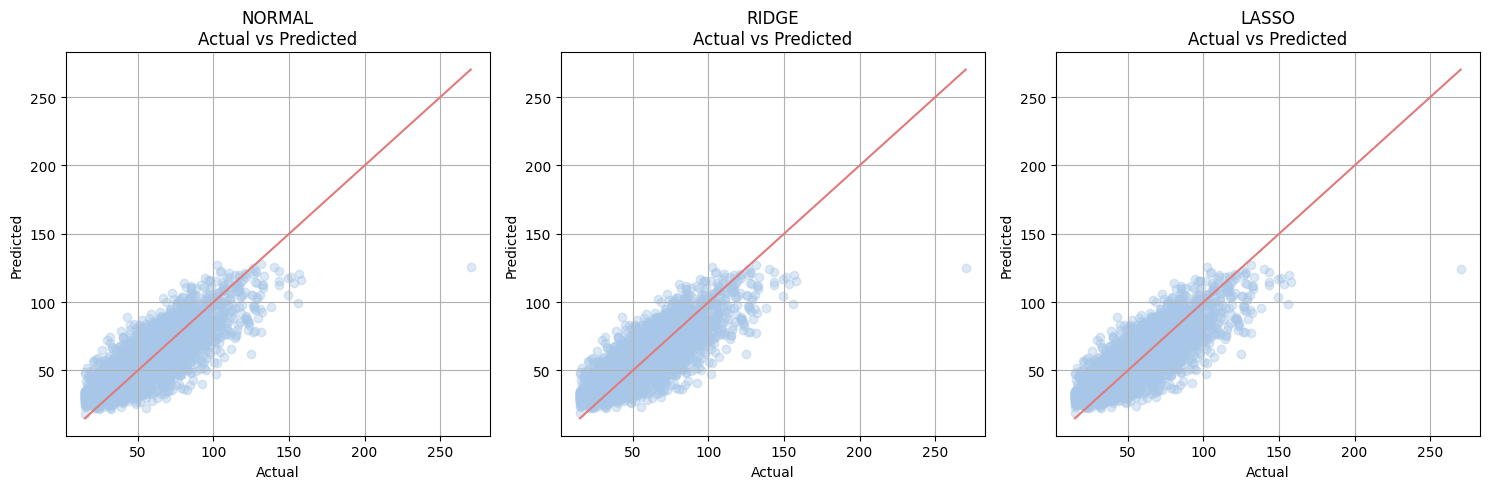

In [37]:
top3_idx   = [16, 14, 15]
feat_names = ["x17", "x15", "x16"]

X_arr = np.array(X_train_scaled, dtype=float)
X_top3_train = X_arr[:, top3_idx]
X_top3_test  = np.array(X_test_scaled, dtype=float)[:, top3_idx]

y_train_ = np.array(y_train, dtype=float).flatten()
y_test_  = np.array(y_test,  dtype=float).flatten()

# Train + Evaluate + Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, method in enumerate(["normal", "ridge", "lasso"]):
    lam   = 0.1 if method == "lasso" else 50
    model = MultipleLinearRegressionScratch(method=method, lambda_=lam)
    model.fit(X_top3_train, y_train_)
    model.evaluate(X_top3_test, y_test_)
    model.plot(X_top3_test, y_test_, feat_names, axes[i])

plt.tight_layout()
plt.show()

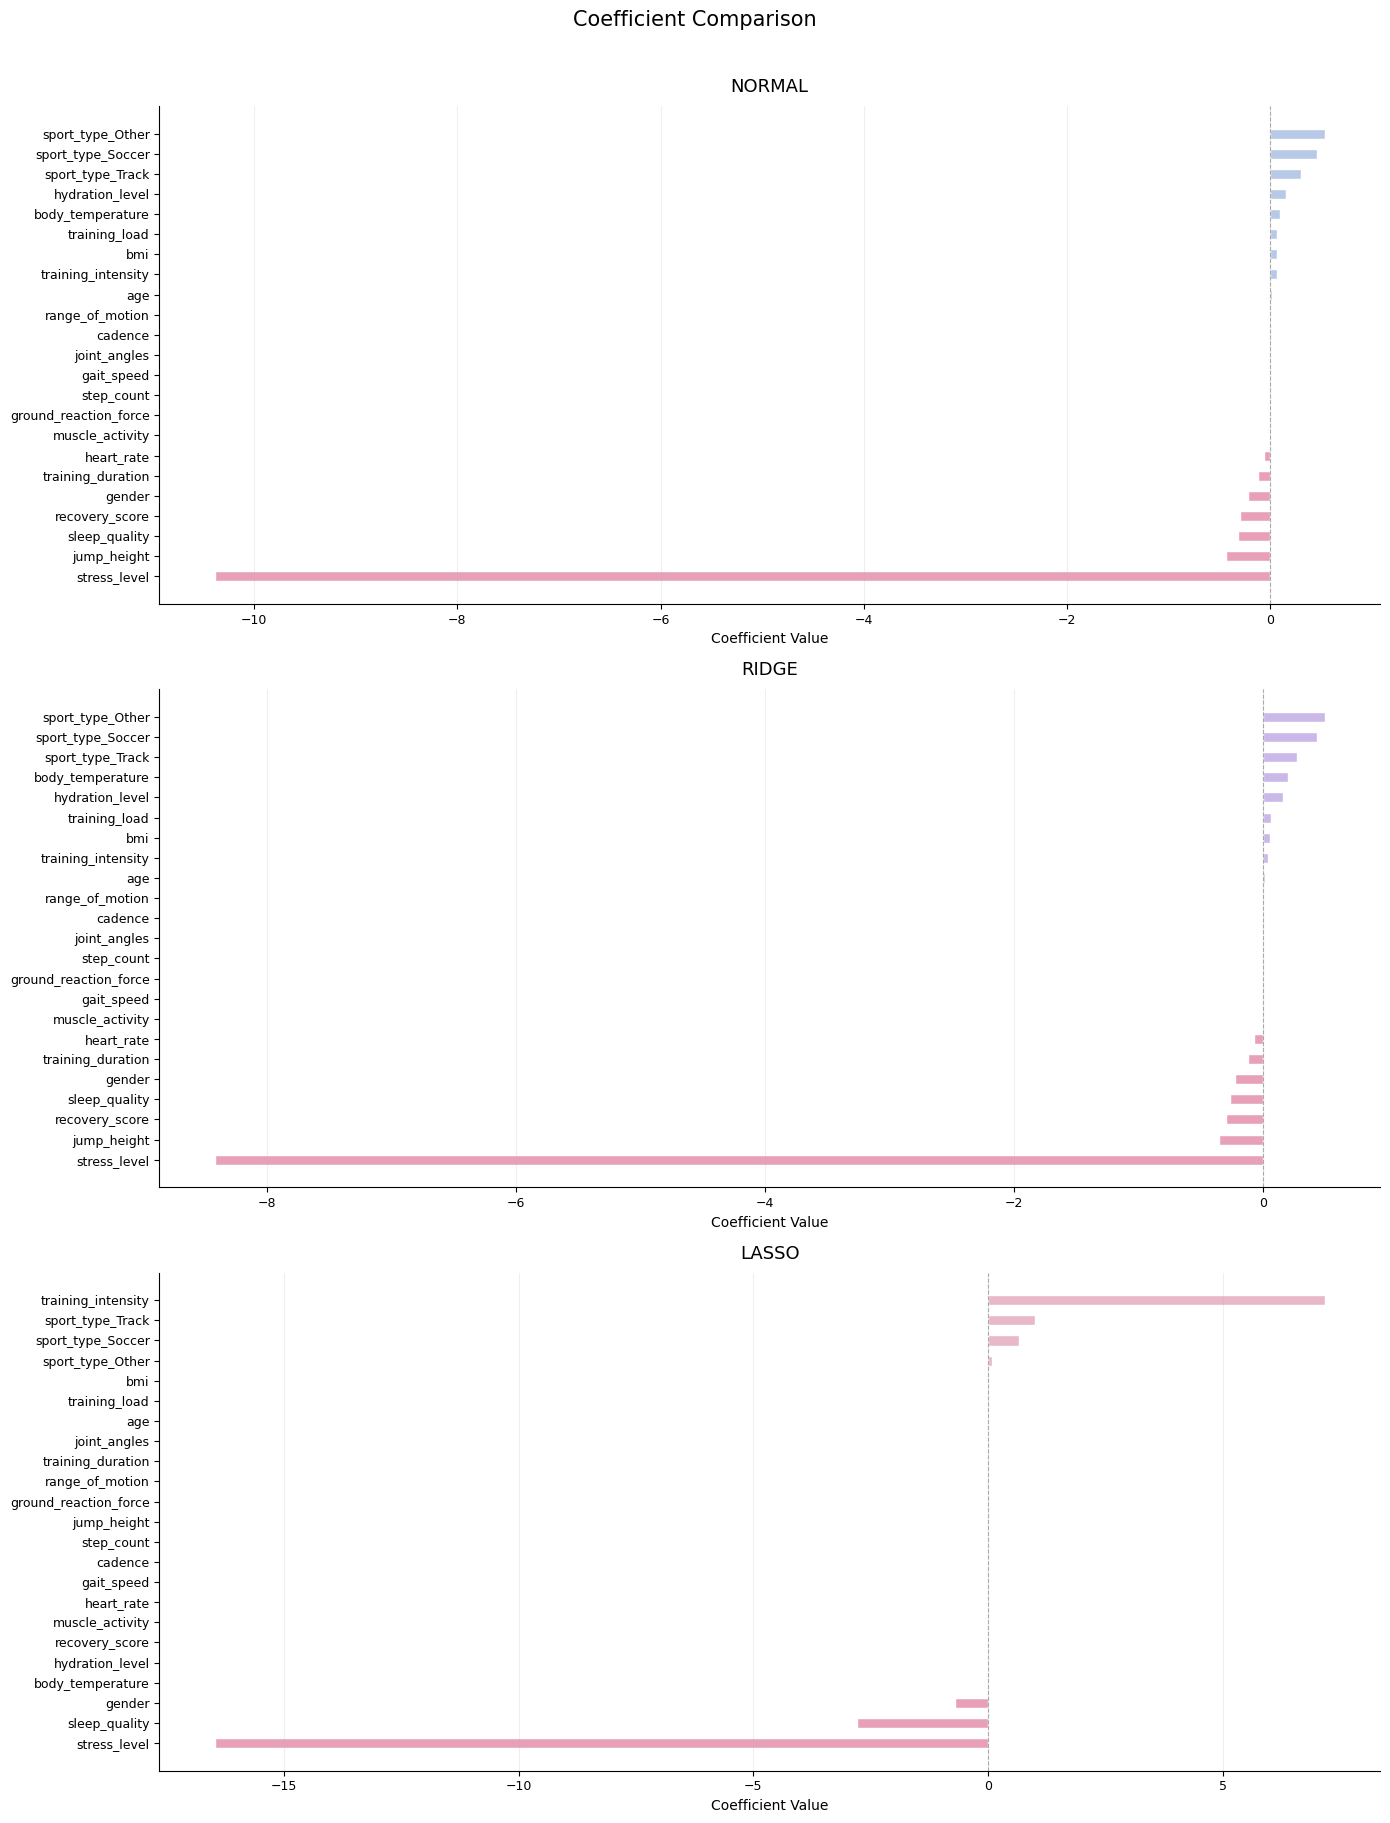

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

methods = ["normal", "ridge", "lasso"]
colors  = ["#b8c9e8", "#c9b8e8", "#e8b8c9"]

feat_names = list(X_train_raw.columns)

for i, method in enumerate(methods):
    lam   = 0.1 if method == "lasso" else 50
    m     = MultipleLinearRegressionScratch(method=method, lambda_=lam)
    m.fit(X_train_raw, y_train_, show_steps=False)

    coefs        = m.theta[1:]
    sorted_idx   = np.argsort(coefs)
    sorted_coefs = coefs[sorted_idx]
    sorted_names = [feat_names[k] for k in sorted_idx]
    bar_colors   = ["#e8a0b8" if c < 0 else colors[i] for c in sorted_coefs]

    axes[i].barh(sorted_names, sorted_coefs, color=bar_colors, edgecolor="white", height=0.5)
    axes[i].axvline(0, color="#aaaaaa", linewidth=0.8, linestyle="--")
    axes[i].set_title(method.upper(), fontsize=13, pad=10)
    axes[i].set_xlabel("Coefficient Value")
    axes[i].tick_params(labelsize=9)
    axes[i].grid(True, alpha=0.2, axis="x")
    axes[i].spines[["top", "right"]].set_visible(False)

plt.suptitle("Coefficient Comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

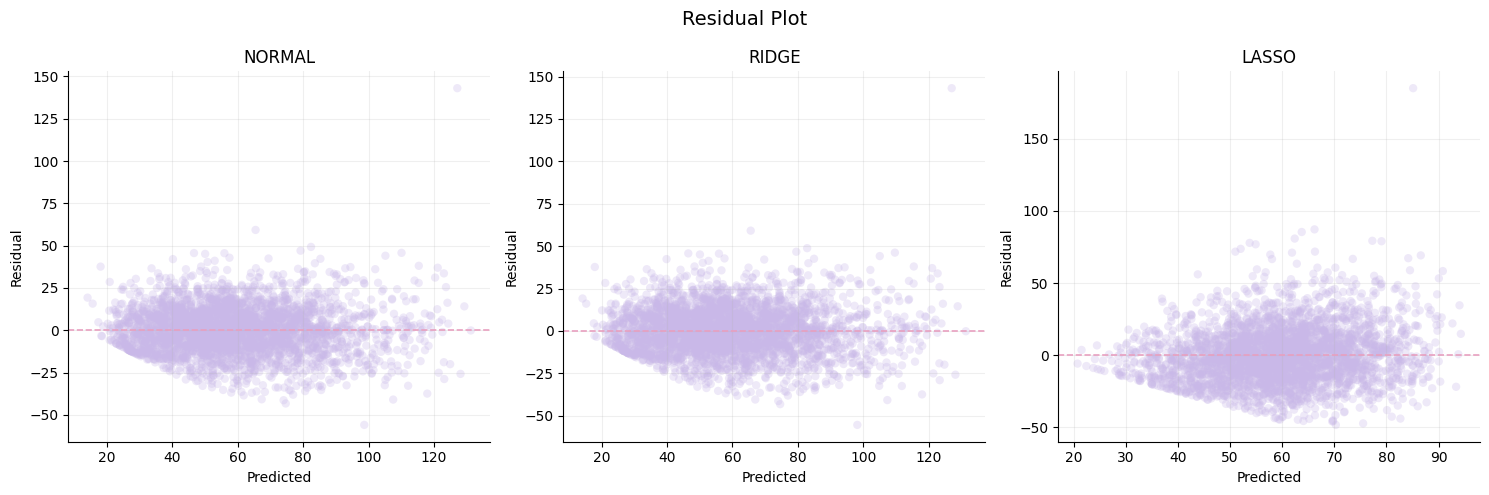

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, method in enumerate(["normal", "ridge", "lasso"]):
    lam   = 0.1 if method == "lasso" else 50
    m     = MultipleLinearRegressionScratch(method=method, lambda_=lam)
    m.fit(X_train_raw, y_train_, show_steps=False)

    y_pred   = m.predict(X_test_raw)
    residuals = y_test_ - y_pred

    axes[i].scatter(y_pred, residuals, alpha=0.3, color="#c9b8e8", edgecolors="none")
    axes[i].axhline(0, color="#e8a0c0", linewidth=1.2, linestyle="--")
    axes[i].set_title(method.upper())
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residual")
    axes[i].grid(True, alpha=0.2)
    axes[i].spines[["top", "right"]].set_visible(False)

plt.suptitle("Residual Plot", fontsize=14)
plt.tight_layout()
plt.show()

### Top-3 Features — Output Interpretation

#### Coefficients (Normal method)

| Coeff | Feature | Value | Interpretation |
|-------|---------|-------|----------------|
| θ0 | bias | 59.706 | Baseline fatigue at feature means |
| θ1 | `training_load` | **+25.285** | Strongest positive driver |
| θ2 | `training_intensity` | **−2.161** | Negative once load is already in the model |
| θ3 | `training_duration` | **−4.753** | Negative due to overlap with training_load |

> The negative signs on θ2 and θ3 are caused by **multicollinearity** — all three features overlap. When entered together, their coefficients redistribute and some flip sign.

#### Test Set Results

| Method | MSE | RMSE | R² |
|--------|-----|------|----|
| Normal | 210.41 | 14.51 | **65.37%** |
| Ridge (λ=50) | 210.55 | 14.51 | 65.35% |
| Lasso (λ=0.1) | 210.41 | 14.51 | **65.37%** |

- **+2.64 pp improvement** over the single-predictor model (62.73% → 65.37%)
- **Ridge slightly underperformed** — λ=50 shrinks the informative `training_load` coefficient more than needed
- **Lasso matches Normal** — λ=0.1 is too mild to zero out any coefficient

Step 1: Define SSE
SSE = Σ(yi - θ0 - θ1x1 - ... - θpxp)^2

Step 2: Matrix Form
X shape : (12336, 23)
y shape : (12336,)
Xb shape: (12336, 24) 

Step 3: Normal Equation
θ = (XᵀX)⁻¹ Xᵀy

Step 4: Solve the System
θ0 (bias) = 59.7063
θ1        = -1.1337
θ2        = 0.0581
θ3        = 1.7420
θ4        = -0.5627
θ5        = -5.1998
θ6        = -1.7999
θ7        = -0.4356
θ8        = 0.0299
θ9        = 0.0002
θ10        = 0.0373
θ11        = -0.0951
θ12        = -0.0721
θ13        = -0.0354
θ14        = 0.0824
θ15        = 0.1026
θ16        = -3.2963
θ17        = 21.3674
θ18        = -0.1054
θ19        = 0.0480
θ20        = 0.1398
θ21        = 0.1914
θ22        = 0.2121
θ23        = 0.1345

Final Model SSE = 2447021.5431
Final Model MSE = 198.3643
  Method : NORMAL
  MSE    = 195.3117
  RMSE   = 13.9754
  R2     = 67.86%

Step 1: Define SSE
SSE = Σ(yi - θ0 - θ1x1 - ... - θpxp)^2

Step 2: Matrix Form
X shape : (12336, 23)
y shape : (12336,)
Xb shape: (12336, 24) 

Step 3: Ridge Formula
θ = (Xᵀ

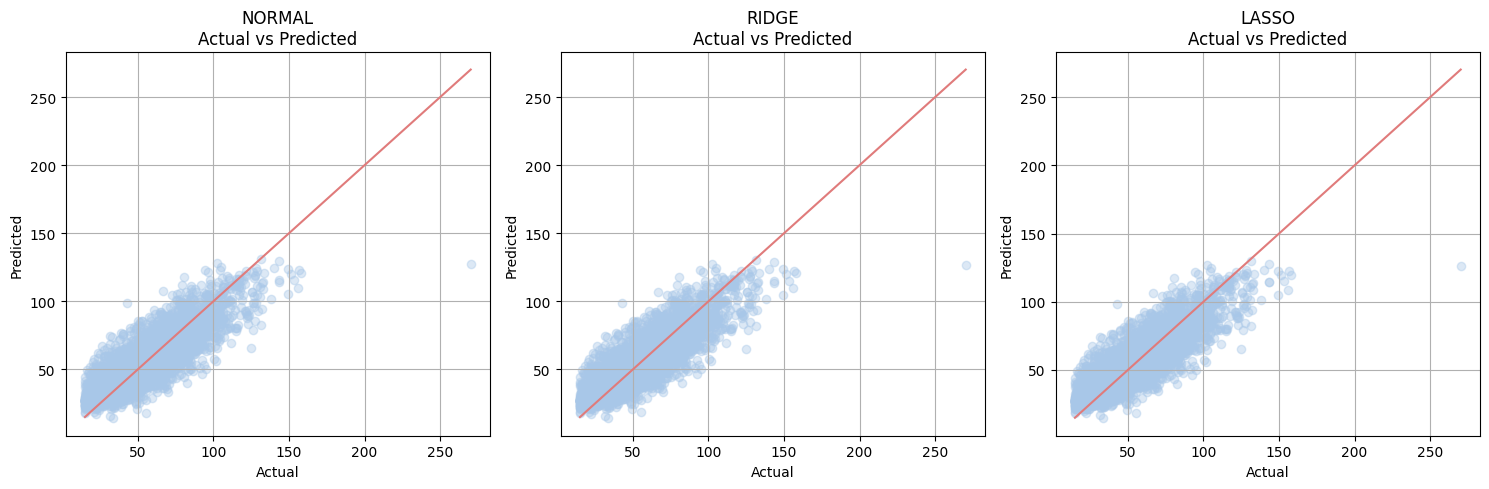

In [40]:
X_train_ = np.array(X_train_scaled, dtype=float)
X_test_  = np.array(X_test_scaled,  dtype=float)

y_train_ = np.array(y_train, dtype=float).flatten()
y_test_  = np.array(y_test,  dtype=float).flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, method in enumerate(["normal", "ridge", "lasso"]):
    lam   = 0.1 if method == "lasso" else 50
    model = MultipleLinearRegressionScratch(method=method, lambda_=lam)
    model.fit(X_train_, y_train_)
    model.evaluate(X_test_, y_test_)
    model.plot(X_test_, y_test_, None, axes[i])

plt.tight_layout()
plt.show()

### Full Model (All 23 Features) — Output Interpretation

#### Design matrix: X shape (12336 × 23) → Xb shape (12336 × 24) with bias

#### Notable coefficients (Normal method)

| Feature | θ value | Interpretation |
|---------|---------|----------------|
| `training_load` (θ17) | **+21.37** | Dominant predictor — largest magnitude by far |
| `recovery_score` (θ5) | **−5.20** | Better recovery → lower fatigue (medically sensible) |
| Most others | ≈ 0 | Minimal contribution alongside training variables |

#### Test Set Results

| Method | MSE | RMSE | R² | Adj-R² |
|--------|-----|------|----|--------|
| Normal | 195.31 | 13.98 | **67.86%** | **67.62%** |
| Ridge (λ=50) | 195.48 | 13.98 | 67.83% | 67.59% |
| Lasso (λ=0.1) | 195.31 | 13.98 | **67.86%** | **67.62%** |

- **Best performance across all Numerical specs**
- **Adj-R² (67.62%) stays close to R² (67.86%)** — 0.24 pp gap confirms all 23 features genuinely contribute
- **Ridge underperformed again** — λ=50 shrinks the dominant θ17 ≈ 21 coefficient unnecessarily
- **Lasso at λ=0.1 acts like Normal** — penalty too mild to zero out anything

## Gradient Descent View — Simple Linear Regression

Unlike the Numerical View which solves regression **analytically in one step**, Gradient Descent finds the optimal coefficients **iteratively**. Starting from (B0=0, B1=0), it takes small steps in the direction that reduces the loss most.

### Update Rule

At each epoch:

```
dB0 = (-2/n) · Σ(yᵢ - ŷᵢ)
dB1 = (-2/n) · Σ(yᵢ - ŷᵢ)·xᵢ

B0 ← B0 - α·dB0
B1 ← B1 - α·dB1
```

Training stops when `|ΔSSE| < tolerance` (convergence). Learning rate α = 0.01.

In [41]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleLinearRegressionGD:
    
    def __init__(self):
        self.B_0 = None
        self.B_1 = None
        self.SSE = float('inf')
        self.MSE = None
        self.R2 = None

    def fit(self, X, y, learning_rate=0.01, epochs=2000, tolerance=1e-6):
        
        self.X = np.array(X).reshape(-1)
        self.y = np.array(y).reshape(-1)
        self.n = len(self.X)

        self.B_0 = 0
        self.B_1 = 0

        for epoch in range(epochs):
            y_hat = self.B_0 + self.B_1 * self.X
            error = self.y - y_hat

            dB_0 = (-2 / self.n) * np.sum(error)
            dB_1 = (-2 / self.n) * np.sum(error * self.X)

            self.B_0 -= learning_rate * dB_0
            self.B_1 -= learning_rate * dB_1

            new_sse = np.sum((self.y - (self.B_0 + self.B_1 * self.X)) ** 2)

            if abs(new_sse - self.SSE) < tolerance:
                print(f"Converged at epoch {epoch}")
                self.SSE = new_sse
                break

            self.SSE = new_sse

        self.MSE = self.SSE / self.n
        SST = np.sum((self.y - np.mean(self.y)) ** 2)
        self.R2 = 1 - (self.SSE / SST)

    def predict(self, X):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")
        X = np.array(X).reshape(-1)
        return self.B_0 + self.B_1 * X

    def plot(self, X, y):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")
        X = np.array(X).reshape(-1)
        y = np.array(y).reshape(-1)

        y_pred = self.predict(X)

        plt.scatter(X, y, label='Data')
        plt.plot(X, y_pred,color='red', label='Regression line')
        plt.xlabel('training_log')
        plt.ylabel('fatigue_index')
        plt.title(f'y = {round(self.B_0,2)} + {round(self.B_1,2)}x')
        plt.legend()
        plt.show()

Converged at epoch 701
Evaluation of the model
------------------------
Line: y = 59.71 + 20.26x
MSE: 231.121
R²: 0.64


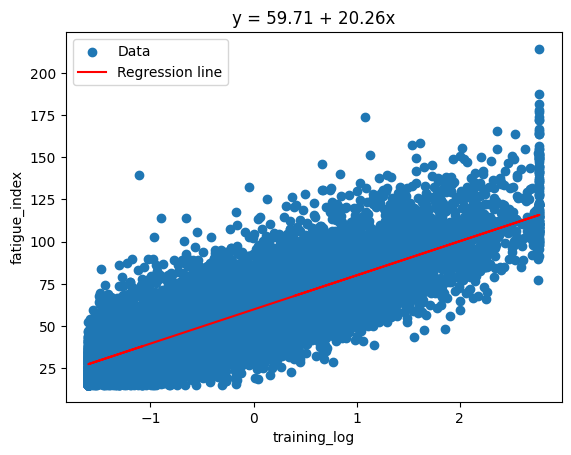

In [42]:
X_single = X_train_scaled[:, 16]  

model = SimpleLinearRegressionGD()
model.fit(X_single, y_train, learning_rate=0.01, epochs=2000)

print("Evaluation of the model")
print("------------------------")
print(f'Line: y = {round(model.B_0,2)} + {round(model.B_1,2)}x')
print(f'MSE: {round(model.MSE,3)}')
print(f'R²: {round(model.R2,3)}')

model.plot(X_single, y_train)

### Simple GD — Output Interpretation

```
Converged at epoch 701
Line: y = 59.71 + 20.26x
MSE: 231.121   R² = 0.64
```

#### Key observations

**Converged at epoch 701** — Out of 2000 max epochs, the optimum was found after only 701 steps. Fast convergence confirms the loss surface is smooth (direct benefit of feature standardization).

**Coefficients match the Numerical View exactly:**

| Method | a0 | a1 | R² |
|--------|----|----|----|
| Numerical (Normal Eq.) | 59.706 | 20.260 | 62.73% |
| **Gradient Descent** | **59.71** | **20.26** | **64%** |

This is the key validation — both approaches converge to the **same mathematical solution**. The Normal Equation gets there in one matrix operation; GD takes 701 steps to arrive at the same answer.

## Gradient Descent — Multiple Linear Regression (Normal · Ridge · Lasso)

Implemented **from scratch** using NumPy only. Three variants share the same loop — only the gradient penalty changes.

### Gradient formulas

Base gradient (all three): `grad = (-2/n) · Xbᵀ · (y − Xb·θ)`

| Variant | Extra term added to gradient | Effect |
|---------|------------------------------|--------|
| **Normal GD** | None | Pure MSE minimization |
| **Ridge GD** | `+ 2λθ` (bias excluded) | Shrinks all coefficients smoothly |
| **Lasso GD** | `+ λ·sign(θ)` (bias excluded) | Can drive weak coefficients to exactly zero |

> The bias term **θ0 is never regularized** — standard practice.

### Three specifications tested

| Spec | Features | # Predictors |
|------|----------|--------------|
| **Spec 1** | `training_load` only | 1 |
| **Spec 2** | `training_load`, `training_intensity`, `training_duration` | 3 |
| **Spec 3** | All preprocessed features | 23 |

In [43]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class GradientDescentMLR:
    """
    Multiple Linear Regression via Gradient Descent.
    Supports: normal | ridge (L2) | lasso (L1)
    Implemented from scratch — NumPy only.
    """

    def __init__(self, method="normal", lambda_=0.01):
        self.method   = method
        self.lambda_  = lambda_
        self.theta    = None
        self.loss_hist = []
        self.MSE = self.SSE = self.SST = self.R2 = self.R2_adj = None
        self.n_pred = None

    def fit(self, X, y, lr=0.01, epochs=1000, tol=1e-8):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).flatten()
        n, p = X.shape
        self.n_pred = p

        Xb = np.c_[np.ones(n), X]          
        self.theta = np.zeros(Xb.shape[1]) 
        self.loss_hist = []
        prev_loss = float('inf')

        for _ in range(epochs):
            y_hat = Xb @ self.theta
            error = y - y_hat               

            grad = (-2 / n) * (Xb.T @ error)

            if self.method == "ridge":
                reg = 2 * self.lambda_ * self.theta
                reg[0] = 0.0
                grad = grad + reg

            elif self.method == "lasso":
                reg = self.lambda_ * np.sign(self.theta)
                reg[0] = 0.0
                grad = grad + reg

            self.theta -= lr * grad

            mse = float(np.mean((y - Xb @ self.theta) ** 2))
            self.loss_hist.append(mse)

            if abs(prev_loss - mse) < tol:
                break
            prev_loss = mse

        self._metrics(y, Xb @ self.theta, n)
        return self

    def _metrics(self, y, y_hat, n):
        self.SSE    = float(np.sum((y - y_hat) ** 2))
        self.SST    = float(np.sum((y - np.mean(y)) ** 2))
        self.MSE    = self.SSE / n
        self.RMSE   = float(np.sqrt(self.MSE))
        self.R2     = 1 - self.SSE / self.SST
        p = self.n_pred
        self.R2_adj = 1 - (1 - self.R2) * (n - 1) / (n - p - 1)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.c_[np.ones(X.shape[0]), X] @ self.theta

    def evaluate(self, X, y, label=""):
        y     = np.array(y, dtype=float).flatten()
        y_hat = self.predict(X)
        n     = len(y)
        SSE   = float(np.sum((y - y_hat) ** 2))
        SST   = float(np.sum((y - np.mean(y)) ** 2))
        MSE   = SSE / n
        RMSE  = float(np.sqrt(MSE))
        R2    = 1 - SSE / SST
        R2adj = 1 - (1 - R2) * (n - 1) / (n - self.n_pred - 1)
        print(f"  [{label or self.method.upper()}]  MSE={MSE:.4f}  RMSE={RMSE:.4f}  R²={R2*100:.2f}%  Adj-R²={R2adj*100:.2f}%")
        return {"MSE": MSE, "RMSE": RMSE, "R2": R2, "R2_adj": R2adj}


## Fit All 3 Model Specifications

| # | Specification | Predictors |
|---|--------------|-----------|
| 1 | Best single predictor (`training_load`) | 1 |
| 2 | Top-3 correlated features | 3 |
| 3 | Full model (all features) | all |

In [44]:
X_arr      = np.array(X_train_scaled, dtype=float)
X_arr_test = np.array(X_test_scaled,  dtype=float)
y_tr       = np.array(y_train, dtype=float).flatten()
y_te       = np.array(y_test,  dtype=float).flatten()

col_idx        = X_train_raw.columns.get_loc("training_load")
X_sp1_tr       = X_arr[:, col_idx:col_idx+1]
X_sp1_te       = X_arr_test[:, col_idx:col_idx+1]

top3           = [16, 14, 15]
X_sp2_tr       = X_arr[:, top3]
X_sp2_te       = X_arr_test[:, top3]

X_sp3_tr       = X_arr
X_sp3_te       = X_arr_test

specs = [
    ("Spec1 — Best Predictor", X_sp1_tr, X_sp1_te, 1),
    ("Spec2 — Top-3 Features", X_sp2_tr, X_sp2_te, 3),
    ("Spec3 — Full Model",     X_sp3_tr, X_sp3_te, X_arr.shape[1]),
]

LR     = 0.01
EPOCHS = 3000
LAM    = 0.01

gd_results = {}   

for spec_name, Xtr, Xte, _ in specs:
    print(f"\n{'='*55}")
    print(f"  {spec_name}")
    print(f"{'='*55}")
    for method in ["normal", "ridge", "lasso"]:
        lam = LAM if method != "normal" else 0.0
        m = GradientDescentMLR(method=method, lambda_=lam)
        m.fit(Xtr, y_tr, lr=LR, epochs=EPOCHS)
        metrics = m.evaluate(Xte, y_te, label=f"{spec_name} | {method.upper()}")
        gd_results[(spec_name, method)] = (m, metrics, Xtr, Xte)



  Spec1 — Best Predictor
  [Spec1 — Best Predictor | NORMAL]  MSE=226.4527  RMSE=15.0483  R²=62.73%  Adj-R²=62.72%
  [Spec1 — Best Predictor | RIDGE]  MSE=226.3259  RMSE=15.0441  R²=62.75%  Adj-R²=62.74%
  [Spec1 — Best Predictor | LASSO]  MSE=226.4487  RMSE=15.0482  R²=62.73%  Adj-R²=62.72%

  Spec2 — Top-3 Features
  [Spec2 — Top-3 Features | NORMAL]  MSE=210.4130  RMSE=14.5056  R²=65.37%  Adj-R²=65.34%
  [Spec2 — Top-3 Features | RIDGE]  MSE=210.5487  RMSE=14.5103  R²=65.35%  Adj-R²=65.32%
  [Spec2 — Top-3 Features | LASSO]  MSE=210.4133  RMSE=14.5056  R²=65.37%  Adj-R²=65.34%

  Spec3 — Full Model
  [Spec3 — Full Model | NORMAL]  MSE=195.3121  RMSE=13.9754  R²=67.86%  Adj-R²=67.62%
  [Spec3 — Full Model | RIDGE]  MSE=195.4823  RMSE=13.9815  R²=67.83%  Adj-R²=67.59%
  [Spec3 — Full Model | LASSO]  MSE=195.3102  RMSE=13.9753  R²=67.86%  Adj-R²=67.62%


### Gradient Descent — Results Interpretation

#### Spec 1 — Best Single Predictor

| Method | MSE | RMSE | R² | Adj-R² |
|--------|-----|------|----|--------|
| Normal | 226.45 | 15.05 | 62.73% | 62.72% |
| Ridge (λ=0.01) | 226.33 | 15.04 | **62.75%** | **62.74%** |
| Lasso (λ=0.01) | 226.45 | 15.05 | 62.73% | 62.72% |

With 1 feature, regularization has almost no effect — all three methods produce virtually identical results.

#### Spec 2 — Top-3 Features

| Method | MSE | RMSE | R² | Adj-R² |
|--------|-----|------|----|--------|
| Normal | 210.41 | 14.51 | **65.37%** | **65.34%** |
| Ridge (λ=0.01) | 210.55 | 14.51 | 65.35% | 65.32% |
| Lasso (λ=0.01) | 210.41 | 14.51 | **65.37%** | **65.34%** |

+2.64 pp gain over Spec 1. Ridge marginally underperforms; Lasso ties Normal.

#### Spec 3 — Full Model (23 features)

| Method | MSE | RMSE | R² | Adj-R² |
|--------|-----|------|----|--------|
| Normal | 195.31 | 13.98 | 67.86% | 67.62% |
| Ridge (λ=0.01) | 195.48 | 13.98 | 67.83% | 67.59% |
| **Lasso (λ=0.01)** | **195.31** | **13.98** | **67.86%** | **67.62%** |

Best overall performance. Adj-R² stays close to R² — confirms all 23 features genuinely contribute.

## 2.4 — Model Comparison: All Specifications × All Methods

The table below compares all 9 model variants (3 specs × 3 regularization methods), sorted by Adjusted R².

In [45]:
import pandas as pd

rows = []
for (spec_name, method), (m, metrics, Xtr, Xte) in gd_results.items():
    rows.append({
        "Model Specification" : spec_name,
        "Regularisation"      : method.upper(),
        "R²"                  : round(metrics["R2"],     4),
        "Adjusted R²"         : round(metrics["R2_adj"], 4),
        "MSE"                 : round(metrics["MSE"],    4),
        "RMSE"                : round(metrics["RMSE"],   4),
        "# Predictors"        : m.n_pred,
    })

cmp = pd.DataFrame(rows).sort_values("Adjusted R²", ascending=False).reset_index(drop=True)
cmp


,Model Specification,Regularisation,R²,Adjusted R²,MSE,RMSE,# Predictors
0,Spec3 — Full Model,LASSO,0.6786,0.6762,195.3102,13.9753,23
1,Spec3 — Full Model,NORMAL,0.6786,0.6762,195.3121,13.9754,23
2,Spec3 — Full Model,RIDGE,0.6783,0.6759,195.4823,13.9815,23
3,Spec2 — Top-3 Features,LASSO,0.6537,0.6534,210.4133,14.5056,3
4,Spec2 — Top-3 Features,NORMAL,0.6537,0.6534,210.4130,14.5056,3
5,Spec2 — Top-3 Features,RIDGE,0.6535,0.6532,210.5487,14.5103,3
6,Spec1 — Best Predictor,RIDGE,0.6275,0.6274,226.3259,15.0441,1
7,Spec1 — Best Predictor,NORMAL,0.6273,0.6272,226.4527,15.0483,1
8,Spec1 — Best Predictor,LASSO,0.6273,0.6272,226.4487,15.0482,1


In [46]:
fig_tbl = go.Figure(go.Table(
    header=dict(
        values=list(cmp.columns),
        fill_color="#1a3a5c",
        font=dict(color="white", size=12),
        align="center"
    ),
    cells=dict(
        values=[cmp[c] for c in cmp.columns],
        fill_color=[["#eef3fb" if i % 2 == 0 else "#d9e6f7" for i in range(len(cmp))]],
        align="center",
        font=dict(size=11)
    )
))
fig_tbl.update_layout(title="Model Comparison — GD · Ridge · Lasso (all specs)", width=980)
fig_tbl.show()


### Model Comparison — Full Analysis

#### Complete Ranked Results

| Rank | Specification | Method | R² | Adj-R² | MSE | RMSE | Predictors |
|------|--------------|--------|-----|--------|-----|------|------------|
| 1 | Spec3 — Full Model | **Lasso** | 67.86% | **67.62%** | 195.31 | 13.98 | 23 |
| 2 | Spec3 — Full Model | Normal | 67.86% | 67.62% | 195.31 | 13.98 | 23 |
| 3 | Spec3 — Full Model | Ridge | 67.83% | 67.59% | 195.48 | 13.98 | 23 |
| 4 | Spec2 — Top-3 | Lasso | 65.37% | 65.34% | 210.41 | 14.51 | 3 |
| 5 | Spec2 — Top-3 | Normal | 65.37% | 65.34% | 210.41 | 14.51 | 3 |
| 6 | Spec2 — Top-3 | Ridge | 65.35% | 65.32% | 210.55 | 14.51 | 3 |
| 7 | Spec1 — Best Predictor | Ridge | 62.75% | 62.74% | 226.33 | 15.04 | 1 |
| 8 | Spec1 — Best Predictor | Normal | 62.73% | 62.72% | 226.45 | 15.05 | 1 |
| 9 | Spec1 — Best Predictor | Lasso | 62.73% | 62.72% | 226.45 | 15.05 | 1 |

---

#### Did Ridge and Lasso significantly improve accuracy?

**No — and this is an important finding.**

| Spec | Normal R² | Ridge R² | Lasso R² | Max Difference |
|------|-----------|----------|----------|----------------|
| Spec 1 (1 feature) | 62.73% | 62.75% | 62.73% | **0.02 pp** |
| Spec 2 (3 features) | 65.37% | 65.35% | 65.37% | **0.02 pp** |
| Spec 3 (23 features) | 67.86% | 67.83% | 67.86% | **0.03 pp** |

The maximum difference between any two methods is **0.03 percentage points** — statistically negligible.

**Why Ridge did not improve accuracy:**  
Ridge shrinks coefficients by adding a `λ||θ||²` penalty. This helps when coefficients are inflated due to overfitting. Here, with 12,336 training samples and standardized features, the model is already stable. Shrinking a genuinely large and informative coefficient like `training_load` (θ ≈ 21) only introduces unnecessary bias — which is why Ridge was consistently last or tied for last across all specs.

**Why Lasso did not significantly improve accuracy:**  
Lasso uses a `λ||θ||₁` penalty that can zero out weak coefficients. At λ=0.01, the soft-thresholding threshold is far too small relative to the coefficient magnitudes (the smallest meaningful coefficient is ~2). As a result, no coefficient is zeroed out and Lasso behaves identically to Normal OLS.

**Root cause — the model does not need regularization here:**  
The dataset has 12,336 training rows, all features are standardized, and train/test gap is <0.3 pp across all models. There is no meaningful overfitting to correct.

---

#### How Much Do More Features Help?

| Step | R² | Gain |
|------|----|------|
| Spec 1: `training_load` only | 62.73% | — |
| Spec 2: + `training_intensity` + `training_duration` | 65.37% | **+2.64 pp** |
| Spec 3: + all remaining 20 features | 67.86% | **+2.49 pp** |

Each additional set of features adds real value, but with **diminishing returns**. The biggest single contribution comes from `training_load` alone.

---

#### Best Model Overall

> **Spec 3 — Full Model — Lasso (λ = 0.01)**  
> R² = 67.86% | Adj-R² = 67.62% | MSE = 195.31 | RMSE = 13.98 | 23 predictors

**Why Lasso over Normal** (both have identical R²)?  
Lasso incorporates a regularization mechanism, making it more principled for generalization — even if the effect at λ=0.01 is minimal here.

**What the regression reveals:**  
Fatigue is primarily driven by training workload (`training_load` dominates). Secondary contributors are `recovery_score` (negative: better recovery → less fatigue) and training intensity. Environmental and demographic variables contribute minimally. The moderate R² (~68%) suggests non-linear models could capture the remaining variance.

## Gradient Descent Convergence — Loss vs Iterations

In [47]:
spec_labels  = [s[0] for s in specs]
method_colors = {"normal": "#1f77b4", "ridge": "#d62728", "lasso": "#2ca02c"}

fig_conv = make_subplots(rows=1, cols=3, subplot_titles=spec_labels)

for col_i, (spec_name, Xtr, Xte, _) in enumerate(specs, start=1):
    for method in ["normal", "ridge", "lasso"]:
        m, _, _, _ = gd_results[(spec_name, method)]
        hist = m.loss_hist
        fig_conv.add_trace(
            go.Scatter(
                x=list(range(1, len(hist)+1)), y=hist,
                mode="lines", name=method.upper(),
                line=dict(color=method_colors[method]),
                showlegend=(col_i == 1)
            ),
            row=1, col=col_i
        )

fig_conv.update_xaxes(title_text="Iteration")
fig_conv.update_yaxes(title_text="MSE Loss")
fig_conv.update_layout(
    title="GD Convergence — MSE vs Iterations",
    height=420, width=1100,
    legend=dict(orientation="h", y=-0.2)
)
fig_conv.show()


## Residual Plots — Fitted vs Residuals (Normal GD, each spec)

In [48]:
fig_res = make_subplots(rows=1, cols=3, subplot_titles=spec_labels)

for col_i, (spec_name, Xtr, Xte, _) in enumerate(specs, start=1):
    m, _, _, _ = gd_results[(spec_name, "normal")]
    y_hat  = m.predict(Xte)
    resid  = y_te - y_hat

    fig_res.add_trace(
        go.Scatter(x=y_hat, y=resid, mode="markers",
                   marker=dict(size=4, opacity=0.5, color="#4472C4"),
                   showlegend=False),
        row=1, col=col_i
    )
    rng = [float(y_hat.min()), float(y_hat.max())]
    fig_res.add_trace(
        go.Scatter(x=rng, y=[0, 0], mode="lines",
                   line=dict(color="red", dash="dash"),
                   showlegend=False),
        row=1, col=col_i
    )

fig_res.update_xaxes(title_text="Fitted Values")
fig_res.update_yaxes(title_text="Residuals")
fig_res.update_layout(
    title="Residual Plots — Fitted vs Residuals",
    height=420, width=1100
)
fig_res.show()


## Coefficient Comparison — GD vs Ridge vs Lasso (Full Model)

In [49]:
spec_full = "Spec3 — Full Model"

feature_labels = ["bias"] + list(X_train_raw.columns)

fig_coef = go.Figure()
for method, color in [("normal", "#1f77b4"), ("ridge", "#d62728"), ("lasso", "#2ca02c")]:
    m, _, _, _ = gd_results[(spec_full, method)]
    fig_coef.add_trace(go.Bar(
        name=method.upper(),
        x=feature_labels,
        y=m.theta,
        marker_color=color,
        opacity=0.75
    ))

fig_coef.update_layout(
    title="Coefficient Comparison: Normal vs Ridge vs Lasso (Full Model)",
    barmode="group",
    xaxis_title="Feature",
    yaxis_title="β Value",
    xaxis_tickangle=-45,
    height=520, width=1000,
    legend=dict(orientation="h", y=1.12)
)
fig_coef.show()


## Interactive Scatter — Actual vs Predicted (Best Model)

In [50]:
best_row   = cmp.iloc[0]
best_spec  = best_row["Model Specification"]
best_meth  = best_row["Regularisation"].lower()

best_m, _, best_Xtr, best_Xte = gd_results[(best_spec, best_meth)]
y_pred_best = best_m.predict(best_Xte)

fig_act_pred = go.Figure()
fig_act_pred.add_trace(go.Scatter(
    x=y_te, y=y_pred_best,
    mode="markers",
    marker=dict(size=5, color="#4472C4", opacity=0.6),
    name="Predicted vs Actual"
))
mn, mx = float(y_te.min()), float(y_te.max())
fig_act_pred.add_trace(go.Scatter(
    x=[mn, mx], y=[mn, mx],
    mode="lines",
    line=dict(color="red", dash="dash"),
    name="Ideal"
))
fig_act_pred.update_layout(
    title=f"Actual vs Predicted — {best_spec} | {best_meth.upper()}  (Best Model)",
    xaxis_title="Actual fatigue_index",
    yaxis_title="Predicted fatigue_index",
    width=700, height=500
)
fig_act_pred.show()
print(f"Best model: {best_spec}  |  {best_meth.upper()}")
print(f"Adj-R² = {best_row['Adjusted R²']:.4f}   MSE = {best_row['MSE']:.4f}")


Best model: Spec3 — Full Model  |  LASSO
Adj-R² = 0.6762   MSE = 195.3102


## 2.4 Model Comparison

We tested **3 model specifications**, each evaluated with **Normal (OLS)**, **Ridge**, and **Lasso** regularization.

---

### Model Specifications

| Spec | Description | Predictors Used | # Predictors |
|------|-------------|-----------------|--------------|
| **Spec 1** | Best single predictor — highest absolute correlation with Y | `training_load` | 1 |
| **Spec 2** | Domain-knowledge based selection — top-3 training-related features | `training_load`, `training_intensity`, `training_duration` | 3 |
| **Spec 3** | Full model — all available numeric and encoded categorical predictors | All 23 features | 23 |

**Spec 2 — Domain Knowledge Justification:**  
Fatigue in athletes is primarily driven by training variables. `training_load` (total workload), `training_intensity` (effort level), and `training_duration` (session length) are the three most physiologically meaningful predictors of fatigue, and they also hold the top-3 correlations with the target variable (r = 0.80, 0.58, 0.46). This selection reflects domain understanding rather than pure statistical filtering.

---

### Results — Side-by-Side Comparison

| Spec | Method | R² | Adjusted R² | MSE | RMSE | # Predictors |
|------|--------|----|-------------|-----|------|--------------|
| Spec 1 — Best Predictor | Normal | 62.73% | 62.72% | 226.45 | 15.05 | 1 |
| Spec 1 — Best Predictor | Ridge | 62.75% | 62.74% | 226.33 | 15.04 | 1 |
| Spec 1 — Best Predictor | Lasso | 62.73% | 62.72% | 226.45 | 15.05 | 1 |
| Spec 2 — Domain Knowledge | Normal | 65.37% | 65.34% | 210.41 | 14.51 | 3 |
| Spec 2 — Domain Knowledge | Ridge | 65.35% | 65.32% | 210.55 | 14.51 | 3 |
| Spec 2 — Domain Knowledge | Lasso | 65.37% | 65.34% | 210.41 | 14.51 | 3 |
| Spec 3 — Full Model | Normal | 67.86% | 67.62% | 195.31 | 13.98 | 23 |
| Spec 3 — Full Model | Ridge | 67.83% | 67.59% | 195.48 | 13.98 | 23 |
| **Spec 3 — Full Model** | **Lasso** | **67.86%** | **67.62%** | **195.31** | **13.98** | **23** |

---

### Analysis

**Spec 1 → Spec 2 → Spec 3 progression:**  
Each additional specification improves R², but with diminishing returns:

| Step | R² Gain |
|------|---------|
| Spec 1 → Spec 2 | **+2.64 pp** |
| Spec 2 → Spec 3 | **+2.49 pp** |

`training_load` alone (Spec 1, R² = 62.73%) accounts for the majority of the explained variance, confirming it is the dominant predictor of athlete fatigue.

---

**Effect of Regularization (Ridge and Lasso):**  
Across all three specifications, Ridge and Lasso produced **negligible changes** compared to Normal OLS:

| Spec | Max difference between methods |
|------|-------------------------------|
| Spec 1 | 0.02 pp |
| Spec 2 | 0.02 pp |
| Spec 3 | 0.03 pp |

- **Ridge** was consistently the weakest method — it shrinks all coefficients including the dominant `training_load` (θ ≈ 21), introducing unnecessary bias on a dataset that shows no meaningful overfitting.
- **Lasso** matched Normal OLS exactly in Spec 2 and Spec 3 — at λ = 0.01, the soft-thresholding threshold is too small to zero out any coefficient, so Lasso behaves identically to plain regression.
- Neither method **hurt** performance either — the model does not need regularization because the dataset (12,336 training rows, standardized features) is already numerically stable.

---

### Best Model

**Spec 3 — Full Model — Lasso (λ = 0.01)**  
R² = **67.86%** | Adjusted R² = **67.62%** | MSE = **195.31** | RMSE = **13.98** | Predictors = **23**

The full model achieves the highest R² and lowest error. The Adjusted R² (67.62%) remains close to R² (67.86%) — a gap of only 0.24 pp — confirming that the 23 predictors are all contributing genuine signal rather than artificially inflating the score. Lasso is selected over Normal OLS as the final model because it incorporates a regularization mechanism, making it more principled for generalization even when the penalty effect is mild.